# 04 — การประมาณอัตราฝนด้วยความสัมพันธ์ Z–R และการสกัดค่าตามตำแหน่ง
## Z–R Quantitative Precipitation Estimation and Spatial Point Extraction

**กรณีศึกษา**

- Radar site: **Omkoi**
- Agency: **Department of Royal Rainmaking and Agricultural Aviation (DRRAA)**
- Radar band: **S-band**
- Event: **observed hail event**
- Date: **18 March 2023**
- QPE input: **Corrected-reflectivity CAPPI**
- Default CAPPI height: **2.0 km MSL**
- 3-D Cartesian grid: อ่านจาก Notebook 03
- Administrative GIS: geoBoundaries Thailand ADM1/ADM2
- Figure text: **English only**
- Teaching explanation: **ภาษาไทย**

---

## แนวคิดหลักของบท

Notebook 03 เปลี่ยนข้อมูลเรดาร์จาก polar volume ให้เป็น Cartesian grid แล้ว  
Notebook 04 จะเปลี่ยนตัวแปรเรดาร์จาก **reflectivity** ไปเป็น **radar-derived rain rate**

ลำดับแนวคิด:

```text
Corrected reflectivity (dBZ)
        ↓
Linear reflectivity factor Z
        ↓
Z–R relationship
        ↓
Radar-derived rain rate R
        ↓
Compare multiple Z–R relations
        ↓
Map + GIS
        ↓
Point extraction
        ↓
GeoTIFF / CSV / reproducible metadata
```

สมการพื้นฐาน:

\[
dBZ = 10\log_{10}(Z)
\]

ดังนั้น

\[
Z = 10^{dBZ/10}
\]

และความสัมพันธ์ Z–R เขียนทั่วไปว่า

\[
Z = aR^b
\]

จึงได้

\[
R=
\left(
\frac{Z}{a}
\right)^{1/b}
\]

โดย:

- \(Z\) = radar reflectivity factor \((mm^6\,m^{-3})\)
- \(R\) = rain rate \((mm\,h^{-1})\)
- \(a,b\) = empirical coefficients

---

> **หลักสำคัญ**
>
> `dBZ ≠ rainfall rate`
>
> `Radar-derived rain rate ≠ surface gauge rainfall`
>
> `QPE ≠ ground truth`
>
> `High ZH in a hail-producing storm can severely bias Z–R rain-rate estimates`
>
> `2-km MSL CAPPI ≠ direct near-surface observation everywhere`

# ผลลัพธ์การเรียนรู้

เมื่อจบ Notebook 04 ผู้เรียนควรสามารถ:

1. อธิบายความแตกต่างระหว่าง dBZ, linear \(Z\) และ rain rate \(R\)
2. แปลง dBZ → \(Z\) → \(R\)
3. อธิบายสมการ \(Z=aR^b\)
4. อธิบายความหมายของ coefficients \(a\) และ \(b\)
5. เปรียบเทียบ Z–R relations หลายชุดแบบ sensitivity analysis
6. อธิบายว่า Z–R relation ไม่มีชุดเดียวที่เหมาะกับฝนทุกชนิด
7. อธิบายผลของ drop-size distribution ต่อ Z–R
8. อธิบายว่าลูกเห็บและ mixed-phase hydrometeors สามารถทำให้ Z–R QPE สูงเกินจริง
9. รักษาความแตกต่างระหว่าง supported dry pixels และ NoData
10. สร้าง radar-derived rain-rate maps ระดับ publication-ready
11. overlay strong-reflectivity contours 50/55/60 dBZ เพื่อเตือนบริเวณ hail-contamination risk
12. เปรียบเทียบความแตกต่างระหว่าง Z–R relations
13. วิเคราะห์ QPE distribution และ extreme-value sensitivity
14. สกัดค่าจาก Cartesian grid ด้วย longitude/latitude
15. สกัดค่าด้วยพิกัด UTM
16. คำนวณระยะจาก requested point ถึง nearest grid-cell center
17. เปรียบเทียบ CAPPI grid-cell extraction กับ nearest native radar gate
18. อธิบายว่า nearest grid cell ≠ nearest native radar gate
19. อธิบายว่า CAPPI rain rate ≠ instantaneous surface rainfall
20. export QPE เป็น GeoTIFF
21. ตรวจ GeoTIFF หลัง export และ reprojection
22. export processing metadata และ figure manifest
23. เขียน Methods และ figure caption จาก parameter จริง
24. เตรียมข้อมูลสำหรับ Notebook 05 — temporal integration และ zonal statistics

**CORE** — ปริญญาตรี  
**ADVANCED** — ปริญญาโท  
**EXPERIMENT** — ปรับ parameter แล้ววิเคราะห์ sensitivity  
**RESEARCH NOTE** — ประเด็นที่ต้องรายงานในงานวิจัย

# Conceptual workflow

```text
Notebook 03
3-D Cartesian reflectivity grid
            ↓
Select 2-km MSL CAPPI
            ↓
Check sampling support
            ↓
Corrected reflectivity
            ↓
dBZ → Z
            ↓
 ┌──────────────────────────┐
 │ Z–R sensitivity relations │
 ├──────────────────────────┤
 │ Marshall–Palmer           │
 │ Convective-like           │
 │ Tropical-like             │
 └──────────────────────────┘
            ↓
Radar-derived rain rate
            ↓
Hail-contamination flags
            ↓
Maps / differences / statistics
            ↓
Point extraction
            ↓
GeoTIFF + CSV
            ↓
Notebook 05
Time integration → accumulated rainfall
```

# 1. ติดตั้งและตรวจสอบไลบรารีสำหรับ Google Colab

In [1]:
# CELL 1 — Install Notebook 04 packages

import sys
import subprocess

PACKAGE_SPECS = [
    "arm-pyart==2.2.5",
    "geopandas>=1.0",
    "pyogrio>=0.10",
    "cartopy>=0.23",
    "pyproj>=3.6",
    "shapely>=2.0",
    "pandas>=2.0",
    "matplotlib>=3.8",
    "netCDF4>=1.6",
    "rasterio>=1.4",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("กำลังติดตั้ง/ตรวจสอบไลบรารีสำหรับ Notebook 04 ...")
subprocess.check_call(cmd)
print("พร้อมใช้งาน")

กำลังติดตั้ง/ตรวจสอบไลบรารีสำหรับ Notebook 04 ...
พร้อมใช้งาน


# 2. เชื่อมต่อ Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive"
    )

except ImportError:
    DRIVE_ROOT = Path.cwd()

    print(
        "ไม่พบ google.colab — "
        "ใช้โฟลเดอร์ปัจจุบันแทน:"
    )

    print(
        DRIVE_ROOT
    )

Mounted at /content/drive


# 3. นำเข้าไลบรารี ตรวจเวอร์ชัน และกำหนดมาตรฐานรูป

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import gc
import gzip
import json
import math
import shutil
import sys
import tempfile
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import (
    BoundaryNorm,
    TwoSlopeNorm,
)

import cartopy
import cartopy.crs as ccrs

import pyart

from pyproj import (
    CRS,
    Transformer,
    Geod,
)

import rasterio

from rasterio.transform import (
    from_origin,
)

from rasterio.warp import (
    calculate_default_transform,
    reproject,
    Resampling,
)

from netCDF4 import (
    num2date,
)

from IPython.display import (
    display,
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "pyart": pyart.__version__,
    "geopandas": gpd.__version__,
    "cartopy": cartopy.__version__,
    "rasterio": rasterio.__version__,
}

display(
    pd.DataFrame(
        SOFTWARE_VERSIONS.items(),
        columns=[
            "software",
            "version",
        ],
    )
)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,pyart,2.2.5
5,geopandas,1.1.4
6,cartopy,0.25.0
7,rasterio,1.5.1


In [4]:
# CELL 4 — Publication-quality plotting and figure provenance

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.constrained_layout.use": True,
})

FIGURE_RECORDS = []


def save_figure(
    fig,
    path,
    **meta,
):
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    FIGURE_RECORDS.append({
        "figure_name": (
            path.name
        ),
        "figure_path": str(
            path
        ),
        **meta,
        "dpi": 300,
    })

    print(
        "Saved:",
        path,
    )

# 4. อ่าน active-event configuration และ readiness จาก Notebook 01–03

Notebook นี้จะไม่สร้าง grid ใหม่จาก UF ถ้าไม่จำเป็น

แต่จะใช้ 3-D Grid NetCDF ที่ Notebook 03 export ไว้แล้ว  
วิธีนี้ช่วยให้:

- ผล QPE สอดคล้องกับ grid geometry ที่ผ่านการตรวจแล้ว
- ลดเวลาใน Colab
- ลดความเสี่ยงที่ Notebook 04 ใช้ gridding parameters ต่างจาก Notebook 03
- Methods มี reproducibility มากขึ้น

In [5]:
# CELL 5 — Load active-event configuration

COURSE_NAME = (
    "Teaching_DRRAA_WeatherRadar_GIS"
)

ROOT = (
    DRIVE_ROOT
    / COURSE_NAME
)

CONFIG_JSON = (
    ROOT
    / "00_config"
    / "course_config.json"
)

if not CONFIG_JSON.exists():
    raise FileNotFoundError(
        "ไม่พบ course_config.json — "
        "ให้รัน Notebook 01 ก่อน"
    )

with CONFIG_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    COURSE_CONFIG = json.load(
        stream
    )

WORKSPACE = COURSE_CONFIG[
    "workspace"
]

ACTIVE_EVENT = COURSE_CONFIG.get(
    "active_event",
    {},
)

if ACTIVE_EVENT.get(
    "event_type"
) != "observed_hail":
    raise RuntimeError(
        "Active event ไม่ใช่ observed_hail"
    )

print(
    "Active event:",
    ACTIVE_EVENT.get(
        "event_id"
    ),
)

print(
    ACTIVE_EVENT.get(
        "event_label"
    )
)

Active event: 20230318_observed_hail_1106_1200
Omkoi observed hail event, 18 March 2023


In [6]:
# CELL 6 — Event-specific paths and Notebook 03 readiness

RADAR_DIR = Path(
    WORKSPACE[
        "radar"
    ]
)

GIS_CANONICAL_DIR = Path(
    WORKSPACE[
        "gis_canonical"
    ]
)

METADATA_DIR = Path(
    WORKSPACE[
        "metadata"
    ]
)

OUTPUT_CSV_DIR = Path(
    WORKSPACE[
        "output_csv"
    ]
)

OUTPUT_GEOTIFF_DIR = Path(
    WORKSPACE[
        "output_geotiff"
    ]
)

EVENT_ROOT = Path(
    WORKSPACE[
        "event_root"
    ]
)

OUTPUT_NETCDF_DIR = (
    EVENT_ROOT
    / "03_output"
    / "netcdf"
)

FIGURE_DIR = (
    Path(
        WORKSPACE[
            "figures"
        ]
    ).parent
    / "04"
)

for folder in [
    OUTPUT_CSV_DIR,
    OUTPUT_GEOTIFF_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


READINESS_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_readiness_check.csv"
)

GRID_CONFIG_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_grid_configuration.csv"
)

PROCESSING_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_processing_metadata.csv"
)

CAPPI_BEAM_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_CAPPI_nearest_beam_sampling.csv"
)

STORM_ROI_02_CSV = (
    OUTPUT_CSV_DIR
    / "02_storm_focus_ROI.csv"
)

for required_file in [
    READINESS_03_CSV,
    GRID_CONFIG_03_CSV,
    PROCESSING_03_CSV,
    CAPPI_BEAM_03_CSV,
    STORM_ROI_02_CSV,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"ไม่พบไฟล์ที่ต้องใช้: {required_file}"
        )


readiness_03 = pd.read_csv(
    READINESS_03_CSV
)

if not (
    readiness_03[
        "status"
    ]
    == "PASS"
).all():
    display(
        readiness_03
    )

    raise RuntimeError(
        "Notebook 03 readiness ยังไม่ผ่าน"
    )


grid_config_03 = pd.read_csv(
    GRID_CONFIG_03_CSV
)

grid_config_lookup = dict(
    zip(
        grid_config_03[
            "parameter"
        ],
        grid_config_03[
            "value"
        ],
    )
)


processing_03 = pd.read_csv(
    PROCESSING_03_CSV
)

processing_03_lookup = dict(
    zip(
        processing_03[
            "parameter"
        ],
        processing_03[
            "value"
        ],
    )
)


cappi_beam_03 = pd.read_csv(
    CAPPI_BEAM_03_CSV
)


storm_roi_02 = pd.read_csv(
    STORM_ROI_02_CSV
)

storm_roi_lookup = dict(
    zip(
        storm_roi_02[
            "parameter"
        ],
        storm_roi_02[
            "value"
        ],
    )
)

print(
    "Notebook 03 readiness: PASS"
)

Notebook 03 readiness: PASS


# 5. ทฤษฎี Reflectivity และการแปลง dBZ → Z

Weather radar วัดพลังงานที่กระเจิงกลับมาจาก hydrometeors แล้วแสดงผลเป็น **reflectivity factor**

ค่า \(Z\) ในระบบ linear มีหน่วย:

\[
mm^6\,m^{-3}
\]

แต่ในการใช้งานเรดาร์นิยมแสดงเป็น logarithmic form:

\[
dBZ = 10\log_{10}(Z)
\]

ดังนั้น:

\[
Z = 10^{dBZ/10}
\]

ตัวอย่าง:

```text
20 dBZ → Z = 100
30 dBZ → Z = 1,000
40 dBZ → Z = 10,000
50 dBZ → Z = 100,000
60 dBZ → Z = 1,000,000
70 dBZ → Z = 10,000,000
```

จุดสำคัญคือ dBZ เพิ่ม 10 dB หมายถึง \(Z\) เพิ่ม **10 เท่า**

ดังนั้น dBZ เป็น logarithmic quantity และไม่ควรถูกนำไปบวกหรือเฉลี่ยแบบ linear โดยไม่เข้าใจความหมายทางกายภาพ

# 6. ทฤษฎีความสัมพันธ์ Z–R

ความสัมพันธ์ระหว่าง radar reflectivity กับ rain rate มักเขียนเป็น:

\[
Z=aR^b
\]

โดย:

- \(Z\) = linear reflectivity factor
- \(R\) = rainfall rate
- \(a,b\) = empirical coefficients

แก้สมการหา \(R\):

\[
R=
\left(
\frac{Z}{a}
\right)^{1/b}
\]

สมการ Z–R เป็น **empirical relationship** ที่ขึ้นกับ:

- drop-size distribution
- ชนิดของฝน
- convective / stratiform regime
- microphysical processes
- season
- geographic region
- radar calibration
- attenuation
- mixed-phase particles

ดังนั้นไม่มี Z–R relation ใดที่เป็นสากลสำหรับทุกสภาพฝน

# 7. Z–R relations ที่ใช้ใน Notebook นี้

ใช้ 3 relations เพื่อสอน **sensitivity analysis**

### 1. Marshall–Palmer

\[
Z=200R^{1.6}
\]

ใช้เป็น baseline teaching relation

### 2. Convective-like sensitivity relation

\[
Z=300R^{1.4}
\]

### 3. Tropical-like sensitivity relation

\[
Z=250R^{1.2}
\]

สอง relations หลังใช้เพื่อแสดงว่าการเปลี่ยน \(a,b\) ส่งผลต่อ estimated rain rate มากเพียงใด โดยเฉพาะที่ high reflectivity

> **สำคัญ**
>
> ใน Notebook นี้ยังไม่มี rain-gauge calibration หรือ validation  
> ดังนั้นการเปรียบเทียบทั้งสามต้องเรียกว่า:
>
> **Z–R sensitivity analysis**
>
> ไม่ใช่:
>
> **validation**

# 8. เหตุการณ์ลูกเห็บกับข้อจำกัดของ Z–R QPE

เหตุการณ์นี้เป็น observed-hail event

ใน convective core ที่มี hail หรือ mixed-phase hydrometeors:

- particles มีขนาดใหญ่
- dielectric properties ต่างจาก raindrops
- reflectivity สามารถสูงมาก
- Z–R relation ที่พัฒนาสำหรับ rainfall สามารถให้ rain rate สูงเกินจริงมาก

ดังนั้นบริเวณ:

```text
ZH ≥ 50 dBZ
ZH ≥ 55 dBZ
ZH ≥ 60 dBZ
```

จะถูก **flag** เพื่อเตือนการตีความ

แต่ Notebook จะไม่:

```text
clip ZH อัตโนมัติ
แทนค่า high ZH ด้วยค่าคงที่
ลบ high-ZH pixels
ประกาศว่า high-ZH ทุก pixel คือ hail
```

เป้าหมายคือให้นิสิตเห็น uncertainty จริง ไม่ซ่อน uncertainty ด้วย preprocessing ที่ไม่ได้อธิบาย

# 9. S-band radar และ QPE

S-band radar มีข้อได้เปรียบด้าน attenuation เมื่อเทียบกับ radar ที่มี wavelength สั้นกว่า เช่น C-band หรือ X-band โดยทั่วไป

อย่างไรก็ตาม S-band QPE ยังมี uncertainty จาก:

- radar calibration
- beam blockage
- anomalous propagation
- vertical profile of reflectivity
- beam overshoot
- bright band
- drop-size distribution
- hail contamination
- Cartesian interpolation

ดังนั้นคำว่า:

```text
S-band
```

ไม่ได้หมายความว่า QPE จะไม่มี bias

# 10. CAPPI 2 km MSL กับ surface rainfall

Notebook นี้ใช้ default:

```text
QPE_CAPPI_MSL_KM = 2.0
```

เพื่อเชื่อมต่อกับบทก่อนหน้าและสร้าง workflow ที่ชัดเจน

แต่ต้องระวังว่า:

```text
2-km MSL CAPPI
≠
surface rainfall observation
```

โดยเฉพาะ hail event นี้ strong core อยู่ห่าง radar ประมาณ 97 km และ Notebook 03 ได้ตรวจ beam geometry แล้ว

หาก 2-km CAPPI อยู่ต่ำกว่า lowest beam center ที่ storm range ค่าที่ได้จะมี interpolation dependence มากขึ้น

ดังนั้น Notebook จะอ่าน `03_CAPPI_nearest_beam_sampling.csv` และรายงาน sampling mismatch ก่อนทำ QPE

In [7]:
# CELL 7 — QPE parameters

QPE_CAPPI_MSL_KM = 2.0

QPE_ZH_MIN_DBZ = 10.0

# ไม่มี upper clipping ใน scientific product
QPE_ZH_MAX_DBZ = None

WET_RAIN_THRESHOLD_MMH = 0.1

HAIL_CAUTION_1_DBZ = 50.0
HAIL_CAUTION_2_DBZ = 55.0
HAIL_CAUTION_3_DBZ = 60.0

HAIL_CAUTION_LEVELS_DBZ = [
    HAIL_CAUTION_1_DBZ,
    HAIL_CAUTION_2_DBZ,
    HAIL_CAUTION_3_DBZ,
]

ZR_RELATIONS = {
    "MP_200_1.6": {
        "label": "Marshall–Palmer",
        "a": 200.0,
        "b": 1.6,
        "equation": "Z = 200 R^1.6",
        "role": "baseline teaching relation",
    },
    "CONV_300_1.4": {
        "label": "Convective-like",
        "a": 300.0,
        "b": 1.4,
        "equation": "Z = 300 R^1.4",
        "role": "sensitivity relation",
    },
    "TROP_250_1.2": {
        "label": "Tropical-like",
        "a": 250.0,
        "b": 1.2,
        "equation": "Z = 250 R^1.2",
        "role": "sensitivity relation",
    },
}

BASE_RELATION = (
    "MP_200_1.6"
)

RELATION_IDS = list(
    ZR_RELATIONS.keys()
)

RAIN_RATE_BOUNDS_MMH = np.array(
    [
        0.1,
        0.5,
        1.0,
        2.0,
        5.0,
        10.0,
        20.0,
        30.0,
        50.0,
        75.0,
        100.0,
        150.0,
    ],
    dtype=float,
)

DIFFERENCE_DISPLAY_LIMIT_MMH = 100.0

GEOTIFF_NODATA = -9999.0

# ---------------------------------------------------------------
# Point extraction
# ---------------------------------------------------------------
POINT_MODE = (
    "strong_echo_reference"
)

MANUAL_POINT_LON = None
MANUAL_POINT_LAT = None

print(
    "QPE parameters loaded."
)

QPE parameters loaded.


In [8]:
# CELL 8 — Export Z–R relation parameters

zr_parameter_rows = []

for relation_id, relation in (
    ZR_RELATIONS.items()
):
    zr_parameter_rows.append({
        "relation_id": (
            relation_id
        ),
        "label": (
            relation[
                "label"
            ]
        ),
        "a": (
            relation[
                "a"
            ]
        ),
        "b": (
            relation[
                "b"
            ]
        ),
        "equation": (
            relation[
                "equation"
            ]
        ),
        "role": (
            relation[
                "role"
            ]
        ),
    })


ZR_PARAMETER_TABLE = pd.DataFrame(
    zr_parameter_rows
)

display(
    ZR_PARAMETER_TABLE
)

ZR_PARAMETER_CSV = (
    OUTPUT_CSV_DIR
    / "04_ZR_relation_parameters.csv"
)

ZR_PARAMETER_TABLE.to_csv(
    ZR_PARAMETER_CSV,
    index=False,
)

,relation_id,label,a,b,equation,role
0,MP_200_1.6,Marshall–Palmer,200.0,1.6,Z = 200 R^1.6,baseline teaching relation
1,CONV_300_1.4,Convective-like,300.0,1.4,Z = 300 R^1.4,sensitivity relation
2,TROP_250_1.2,Tropical-like,250.0,1.2,Z = 250 R^1.2,sensitivity relation


# 11. อ่าน full-domain 3-D Grid NetCDF จาก Notebook 03

Notebook 03 export full-domain Grid เป็น NetCDF

Notebook 04 จะอ่านไฟล์นั้นกลับมาใหม่ด้วย Py-ART แทนการใช้ object ที่ยังค้างอยู่ใน memory

การ reopen file เป็น validation ขั้นหนึ่งว่า:

```text
output ของ Notebook 03
สามารถเป็น input ของ Notebook 04 ได้จริง
```

In [9]:
# CELL 9 — Locate and read Notebook 03 full-domain Grid NetCDF

configured_grid_path = Path(
    str(
        grid_config_lookup[
            "full_grid_NetCDF"
        ]
    )
)

if configured_grid_path.exists():
    FULL_GRID_NETCDF = (
        configured_grid_path
    )

else:
    candidates = sorted(
        OUTPUT_NETCDF_DIR.glob(
            "03_peak_full_domain_3D_ZH_*UTC.nc"
        )
    )

    if not candidates:
        raise FileNotFoundError(
            "ไม่พบ full-domain 3-D Grid NetCDF จาก Notebook 03"
        )

    FULL_GRID_NETCDF = (
        candidates[
            -1
        ]
    )


print(
    "Reading:",
    FULL_GRID_NETCDF
)

full_grid = pyart.io.read_grid(
    str(
        FULL_GRID_NETCDF
    )
)

FIELD_Z = str(
    grid_config_lookup[
        "field"
    ]
)

if FIELD_Z not in (
    full_grid.fields
):
    raise KeyError(
        f"ไม่พบ field {FIELD_Z} ใน Grid NetCDF"
    )

print(
    "Grid loaded."
)

print(
    "Shape:",
    full_grid.fields[
        FIELD_Z
    ][
        "data"
    ].shape,
)

Reading: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/netcdf/03_peak_full_domain_3D_ZH_20230318_111202UTC.nc
Grid loaded.
Shape: (38, 441, 441)


In [10]:
# CELL 10 — Grid coordinates and observation metadata

grid_z_km = (
    np.asarray(
        full_grid.z[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

grid_x_km = (
    np.asarray(
        full_grid.x[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

grid_y_km = (
    np.asarray(
        full_grid.y[
            "data"
        ],
        dtype=float,
    )
    / 1000.0
)

radar_lat = float(
    full_grid.origin_latitude[
        "data"
    ][0]
)

radar_lon = float(
    full_grid.origin_longitude[
        "data"
    ][0]
)

radar_altitude_m_MSL = float(
    grid_config_lookup[
        "radar_altitude_m_MSL"
    ]
)

selected_filename = str(
    grid_config_lookup[
        "source_file"
    ]
)

observation_time_UTC = pd.Timestamp(
    str(
        grid_config_lookup[
            "observation_time_UTC"
        ]
    )
)

print(
    "Radar origin:",
    radar_lat,
    radar_lon,
)

print(
    "Grid z:",
    f"{grid_z_km.min():.1f}–"
    f"{grid_z_km.max():.1f} km MSL",
)

print(
    "Source radar file:",
    selected_filename,
)

print(
    "Observation time UTC:",
    observation_time_UTC,
)

Radar origin: 17.798207465277777 98.4323263888889
Grid z: 1.5–20.0 km MSL
Source radar file: 20230318111202.uf.gz
Observation time UTC: 2023-03-18 11:12:02+00:00


In [11]:
# CELL 11 — Select QPE CAPPI

qpe_level_index = int(
    np.argmin(
        np.abs(
            grid_z_km
            - QPE_CAPPI_MSL_KM
        )
    )
)

QPE_ACTUAL_HEIGHT_KM_MSL = float(
    grid_z_km[
        qpe_level_index
    ]
)

ZH_CAPPI = np.ma.asarray(
    full_grid.fields[
        FIELD_Z
    ][
        "data"
    ][
        qpe_level_index
    ]
)

grid_lon, grid_lat = (
    full_grid.get_point_longitude_latitude(
        level=(
            qpe_level_index
        )
    )
)

print(
    "Requested QPE CAPPI:",
    QPE_CAPPI_MSL_KM,
    "km MSL",
)

print(
    "Actual Grid level:",
    QPE_ACTUAL_HEIGHT_KM_MSL,
    "km MSL",
)

print(
    "Valid CAPPI pixels:",
    ZH_CAPPI.count(),
)

Requested QPE CAPPI: 2.0 km MSL
Actual Grid level: 2.0 km MSL
Valid CAPPI pixels: 12379


# 12. ตรวจ sampling support ของ QPE CAPPI

ก่อนแปลง ZH เป็น rain rate ต้องตอบคำถามว่า:

> ระดับ 2 km MSL ถูก native radar beam สนับสนุนโดยตรงมากน้อยเพียงใดที่ตำแหน่ง storm core?

Notebook 03 คำนวณ nearest native beam ไว้แล้ว

ค่าที่ใช้ใน QPE จึงถูกเชื่อมโยงกลับไปยัง radar geometry ไม่ใช่ดูเฉพาะ Cartesian image

In [12]:
# CELL 12 — Sampling diagnostic for QPE CAPPI

sampling_match = (
    cappi_beam_03.loc[
        np.isclose(
            cappi_beam_03[
                "requested_CAPPI_km_MSL"
            ],
            QPE_CAPPI_MSL_KM,
        )
    ]
)

if sampling_match.empty:
    raise RuntimeError(
        "ไม่พบ sampling diagnostic สำหรับ QPE CAPPI level"
    )

sampling_match = (
    sampling_match.iloc[
        0
    ]
)

QPE_NEAREST_ELEVATION_DEG = float(
    sampling_match[
        "nearest_native_elevation_deg"
    ]
)

QPE_NEAREST_BEAM_KM_MSL = float(
    sampling_match[
        "nearest_beam_center_km_MSL"
    ]
)

QPE_VERTICAL_MISMATCH_KM = float(
    sampling_match[
        "absolute_vertical_mismatch_km"
    ]
)

display(
    pd.DataFrame({
        "parameter": [
            "QPE_CAPPI_km_MSL",
            "nearest_native_elevation_deg",
            "nearest_beam_center_km_MSL",
            "absolute_vertical_mismatch_km",
            "reference_range_km",
        ],
        "value": [
            QPE_ACTUAL_HEIGHT_KM_MSL,
            QPE_NEAREST_ELEVATION_DEG,
            QPE_NEAREST_BEAM_KM_MSL,
            QPE_VERTICAL_MISMATCH_KM,
            float(
                sampling_match[
                    "reference_range_km"
                ]
            ),
        ],
    })
)

if (
    QPE_NEAREST_BEAM_KM_MSL
    > QPE_ACTUAL_HEIGHT_KM_MSL
):
    print()
    print(
        "CAUTION: At the main strong-echo reference range, "
        "the nearest native beam center is above the selected QPE CAPPI."
    )

,parameter,value
0,QPE_CAPPI_km_MSL,2.000000
1,nearest_native_elevation_deg,0.500000
2,nearest_beam_center_km_MSL,2.568526
3,absolute_vertical_mismatch_km,0.568526
4,reference_range_km,96.768950



CAUTION: At the main strong-echo reference range, the nearest native beam center is above the selected QPE CAPPI.


# 13. Supported dry pixels กับ NoData ต้องแยกจากกัน

นี่เป็นหลักสำคัญมากของ radar QPE

### กรณีที่ 1 — radar grid valid แต่ reflectivity ต่ำกว่า QPE threshold

```text
valid radar support
+
ZH < 10 dBZ
→
rain rate = 0 mm h⁻¹
```

### กรณีที่ 2 — radar grid ไม่มีข้อมูล

```text
No radar support
→
NoData / masked
```

หากเอาสองกรณีนี้มารวมกัน:

- wet-area fraction จะผิด
- spatial mean จะผิด
- temporal accumulation ใน Notebook 05 จะผิด
- zonal statistics จะผิด

ดังนั้น QPE function ต้องรักษา mask เดิมไว้ และเปลี่ยน weak-but-valid reflectivity เป็น rainfall = 0

In [13]:
# CELL 13 — dBZ → linear Z helper

def dbz_to_linear_z(
    dbz,
):
    dbz_ma = np.ma.asarray(
        dbz
    )

    return np.ma.power(
        10.0,
        dbz_ma
        / 10.0,
    )


LINEAR_Z_CAPPI = (
    dbz_to_linear_z(
        ZH_CAPPI
    )
)

print(
    "Linear-Z conversion completed."
)

Linear-Z conversion completed.


In [14]:
# CELL 14 — Z–R rain-rate function with support-aware masking

def radar_rain_rate_from_dbz(
    dbz,
    *,
    a,
    b,
    zh_min_dbz=QPE_ZH_MIN_DBZ,
):
    dbz_ma = np.ma.asarray(
        dbz
    )

    original_mask = np.ma.getmaskarray(
        dbz_ma
    )

    dbz_values = dbz_ma.filled(
        np.nan
    )

    valid_support = (
        ~original_mask
        & np.isfinite(
            dbz_values
        )
    )

    rain_rate = np.full(
        dbz_values.shape,
        np.nan,
        dtype=float,
    )

    # Valid radar support but weak/no-rain reflectivity:
    # explicitly assign 0 mm h^-1.
    dry_supported = (
        valid_support
        & (
            dbz_values
            < zh_min_dbz
        )
    )

    rain_rate[
        dry_supported
    ] = 0.0

    wet_supported = (
        valid_support
        & (
            dbz_values
            >= zh_min_dbz
        )
    )

    if wet_supported.any():
        linear_z = np.power(
            10.0,
            dbz_values[
                wet_supported
            ]
            / 10.0,
        )

        rain_rate[
            wet_supported
        ] = np.power(
            linear_z
            / float(
                a
            ),
            1.0
            / float(
                b
            ),
        )

    return np.ma.array(
        rain_rate,
        mask=(
            ~valid_support
        ),
    )

In [15]:
# CELL 15 — Calculate rain-rate products for all Z–R relations

RAIN_RATE_PRODUCTS = {}

for relation_id, relation in (
    ZR_RELATIONS.items()
):
    rainfall = (
        radar_rain_rate_from_dbz(
            ZH_CAPPI,
            a=(
                relation[
                    "a"
                ]
            ),
            b=(
                relation[
                    "b"
                ]
            ),
            zh_min_dbz=(
                QPE_ZH_MIN_DBZ
            ),
        )
    )

    RAIN_RATE_PRODUCTS[
        relation_id
    ] = rainfall

    print(
        relation_id,
        "valid pixels =",
        rainfall.count(),
    )

MP_200_1.6 valid pixels = 12379
CONV_300_1.4 valid pixels = 12379
TROP_250_1.2 valid pixels = 12379


# 14. ทำไม high dBZ จึงทำให้ Z–R rain rate เพิ่มอย่างรวดเร็ว

เนื่องจาก:

\[
Z=10^{dBZ/10}
\]

ค่าที่ 60–70 dBZ ทำให้ \(Z\) มีขนาดใหญ่มาก

เมื่อนำเข้า Z–R relation ค่า \(R\) อาจสูงมากจนไม่สมเหตุสมผลสำหรับ liquid rainfall โดยเฉพาะเมื่อ reflectivity สูงจาก hail

ดังนั้น Notebook จะสร้าง reference table ที่:

```text
20
30
40
50
55
60
65
70 dBZ
```

เพื่อให้นิสิตเห็น nonlinear sensitivity โดยตรง

In [16]:
# CELL 16 — Theoretical Z–R reference table

REFERENCE_DBZ = np.array(
    [
        20.0,
        30.0,
        40.0,
        50.0,
        55.0,
        60.0,
        65.0,
        70.0,
    ]
)

reference_rows = []

for dbz_value in (
    REFERENCE_DBZ
):
    z_value = float(
        10.0**(
            dbz_value
            / 10.0
        )
    )

    row = {
        "dBZ": (
            dbz_value
        ),
        "linear_Z_mm6_m-3": (
            z_value
        ),
    }

    for relation_id, relation in (
        ZR_RELATIONS.items()
    ):
        rain_rate = float(
            (
                z_value
                / relation[
                    "a"
                ]
            )**(
                1.0
                / relation[
                    "b"
                ]
            )
        )

        row[
            f"R_{relation_id}_mmh"
        ] = rain_rate

    reference_rows.append(
        row
    )


ZR_REFERENCE_TABLE = pd.DataFrame(
    reference_rows
)

display(
    ZR_REFERENCE_TABLE
)

ZR_REFERENCE_CSV = (
    OUTPUT_CSV_DIR
    / "04_ZR_reference_values.csv"
)

ZR_REFERENCE_TABLE.to_csv(
    ZR_REFERENCE_CSV,
    index=False,
)

,dBZ,linear_Z_mm6_m-3,R_MP_200_1.6_mmh,R_CONV_300_1.4_mmh,R_TROP_250_1.2_mmh
0,20.0,1.000000e+02,0.648420,0.456246,0.465997
1,30.0,1.000000e+03,2.734364,2.363115,3.174802
2,40.0,1.000000e+04,11.530715,12.239693,21.629675
3,50.0,1.000000e+05,48.624624,63.395181,147.361260
4,55.0,3.162278e+05,99.851882,144.277665,384.636056
5,60.0,1.000000e+06,205.048338,328.353735,1003.960577
6,65.0,3.162278e+06,421.071893,747.282510,2620.494944
7,70.0,1.000000e+07,864.681670,1700.699857,6839.903787


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_fig01_ZR_theoretical_sensitivity.png


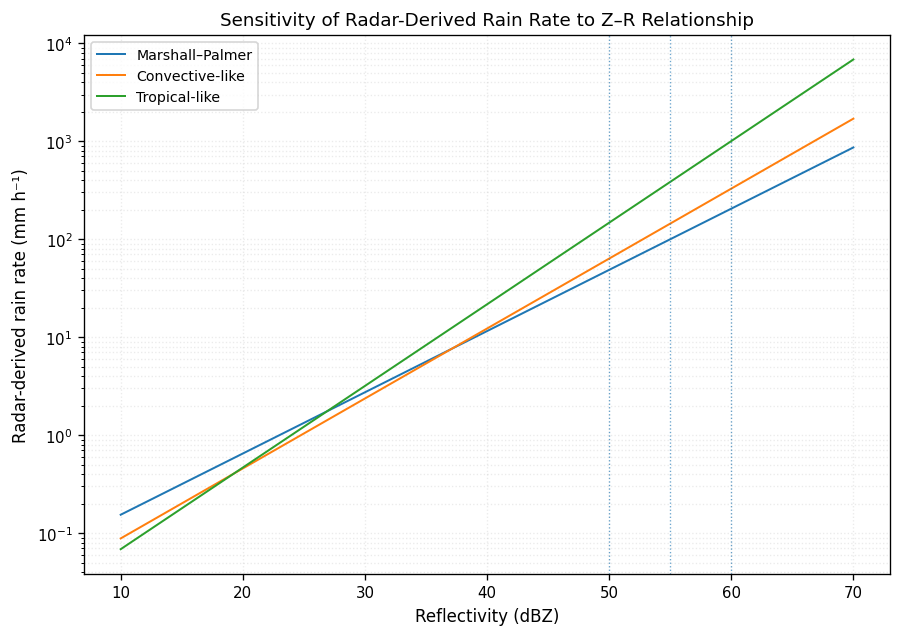

In [17]:
# CELL 17 — Z–R theoretical sensitivity figure

dbz_curve = np.linspace(
    10.0,
    70.0,
    601,
)

z_curve = np.power(
    10.0,
    dbz_curve
    / 10.0,
)

fig = plt.figure(
    figsize=(
        7.4,
        5.2,
    )
)

ax = fig.add_subplot(
    111
)

for relation_id, relation in (
    ZR_RELATIONS.items()
):
    rain_curve = np.power(
        z_curve
        / relation[
            "a"
        ],
        1.0
        / relation[
            "b"
        ],
    )

    ax.plot(
        dbz_curve,
        rain_curve,
        label=(
            relation[
                "label"
            ]
        ),
    )

for threshold in (
    HAIL_CAUTION_LEVELS_DBZ
):
    ax.axvline(
        threshold,
        linestyle=":",
        linewidth=0.8,
        alpha=0.65,
    )

ax.set_yscale(
    "log"
)

ax.set_xlabel(
    "Reflectivity (dBZ)"
)

ax.set_ylabel(
    "Radar-derived rain rate (mm h⁻¹)"
)

ax.set_title(
    "Sensitivity of Radar-Derived Rain Rate to Z–R Relationship"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
    which="both",
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "04_fig01_ZR_theoretical_sensitivity.png"
)

save_figure(
    fig,
    F,
    product="Z-R theoretical sensitivity",
    processing=(
        "Analytical conversion from dBZ to rain rate; "
        "not event validation."
    ),
    units="mm h-1",
)

plt.show()

# 15. Hail-contamination caution flags

Notebook จะสร้าง flag จาก corrected reflectivity:

```text
0 = valid radar support and ZH < 50 dBZ
1 = ZH ≥ 50 dBZ
2 = ZH ≥ 55 dBZ
3 = ZH ≥ 60 dBZ
```

Flag นี้ไม่ได้บอกว่า pixel ใดเป็น hail

แต่หมายถึง:

> บริเวณที่การตีความ Z–R rain rate ควรระมัดระวังมากขึ้น เพราะ reflectivity สูงมากใน observed-hail event

In [18]:
# CELL 18 — Hail-contamination caution flags

zh_values = ZH_CAPPI.filled(
    np.nan
)

zh_valid = (
    ~np.ma.getmaskarray(
        ZH_CAPPI
    )
    & np.isfinite(
        zh_values
    )
)

HAIL_CAUTION_FLAG = np.full(
    zh_values.shape,
    -1,
    dtype=np.int8,
)

HAIL_CAUTION_FLAG[
    zh_valid
] = 0

HAIL_CAUTION_FLAG[
    zh_valid
    & (
        zh_values
        >= HAIL_CAUTION_1_DBZ
    )
] = 1

HAIL_CAUTION_FLAG[
    zh_valid
    & (
        zh_values
        >= HAIL_CAUTION_2_DBZ
    )
] = 2

HAIL_CAUTION_FLAG[
    zh_valid
    & (
        zh_values
        >= HAIL_CAUTION_3_DBZ
    )
] = 3


hail_flag_summary = pd.DataFrame({
    "category": [
        "valid_ZH_lt_50dBZ",
        "ZH_ge_50dBZ",
        "ZH_ge_55dBZ",
        "ZH_ge_60dBZ",
    ],
    "pixel_count": [
        int(
            (
                zh_valid
                & (
                    zh_values
                    < 50.0
                )
            ).sum()
        ),
        int(
            (
                zh_valid
                & (
                    zh_values
                    >= 50.0
                )
            ).sum()
        ),
        int(
            (
                zh_valid
                & (
                    zh_values
                    >= 55.0
                )
            ).sum()
        ),
        int(
            (
                zh_valid
                & (
                    zh_values
                    >= 60.0
                )
            ).sum()
        ),
    ],
})

display(
    hail_flag_summary
)

HAIL_FLAG_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "04_hail_contamination_flag_summary.csv"
)

hail_flag_summary.to_csv(
    HAIL_FLAG_SUMMARY_CSV,
    index=False,
)

,category,pixel_count
0,valid_ZH_lt_50dBZ,12137
1,ZH_ge_50dBZ,242
2,ZH_ge_55dBZ,69
3,ZH_ge_60dBZ,27


# 16. QPE summary statistics

Rain-rate distribution มักมีลักษณะ skewed อย่างมาก

ดังนั้นไม่ควรรายงานเฉพาะ mean

Notebook จะรายงาน:

- valid pixel count
- wet pixel count
- wet fraction
- mean
- median
- P90
- P95
- P99
- maximum
- fraction of wet pixels overlapping ≥50/55/60 dBZ

และรายงานทั้ง:

```text
full Cartesian domain
storm-focused ROI
```

In [19]:
# CELL 19 — Storm ROI masks from Notebook 02

roi_xmin_km = float(
    storm_roi_lookup[
        "xmin_km"
    ]
)

roi_xmax_km = float(
    storm_roi_lookup[
        "xmax_km"
    ]
)

roi_ymin_km = float(
    storm_roi_lookup[
        "ymin_km"
    ]
)

roi_ymax_km = float(
    storm_roi_lookup[
        "ymax_km"
    ]
)

x_roi_mask = (
    (
        grid_x_km
        >= roi_xmin_km
    )
    & (
        grid_x_km
        <= roi_xmax_km
    )
)

y_roi_mask = (
    (
        grid_y_km
        >= roi_ymin_km
    )
    & (
        grid_y_km
        <= roi_ymax_km
    )
)

print(
    "Storm ROI:",
    f"x={roi_xmin_km:.1f} to {roi_xmax_km:.1f} km, "
    f"y={roi_ymin_km:.1f} to {roi_ymax_km:.1f} km",
)

Storm ROI: x=-10.3 to 179.6 km, y=-42.2 to 101.5 km


In [20]:
# CELL 20 — QPE summary function

def summarize_rain_rate(
    rainfall,
    *,
    relation_id,
    domain_name,
    spatial_mask=None,
):
    rain = np.ma.asarray(
        rainfall
    )

    rain_values = rain.filled(
        np.nan
    )

    valid = (
        ~np.ma.getmaskarray(
            rain
        )
        & np.isfinite(
            rain_values
        )
    )

    if spatial_mask is not None:
        valid = (
            valid
            & spatial_mask
        )

    valid_values = rain_values[
        valid
    ]

    wet = (
        valid
        & (
            rain_values
            >= WET_RAIN_THRESHOLD_MMH
        )
    )

    wet_values = rain_values[
        wet
    ]

    if wet.sum() > 0:
        hail50_fraction = float(
            (
                wet
                & (
                    zh_values
                    >= 50.0
                )
            ).sum()
            / wet.sum()
        )

        hail55_fraction = float(
            (
                wet
                & (
                    zh_values
                    >= 55.0
                )
            ).sum()
            / wet.sum()
        )

        hail60_fraction = float(
            (
                wet
                & (
                    zh_values
                    >= 60.0
                )
            ).sum()
            / wet.sum()
        )

    else:
        hail50_fraction = np.nan
        hail55_fraction = np.nan
        hail60_fraction = np.nan

    return {
        "relation_id": (
            relation_id
        ),
        "label": (
            ZR_RELATIONS[
                relation_id
            ][
                "label"
            ]
        ),
        "domain": (
            domain_name
        ),
        "valid_pixel_count": int(
            valid.sum()
        ),
        "wet_pixel_count": int(
            wet.sum()
        ),
        "wet_fraction_of_valid": (
            float(
                wet.sum()
                / valid.sum()
            )
            if valid.sum()
            else np.nan
        ),
        "mean_rain_rate_mmh": (
            float(
                np.nanmean(
                    valid_values
                )
            )
            if valid_values.size
            else np.nan
        ),
        "median_rain_rate_mmh": (
            float(
                np.nanmedian(
                    valid_values
                )
            )
            if valid_values.size
            else np.nan
        ),
        "P90_rain_rate_mmh": (
            float(
                np.nanpercentile(
                    valid_values,
                    90,
                )
            )
            if valid_values.size
            else np.nan
        ),
        "P95_rain_rate_mmh": (
            float(
                np.nanpercentile(
                    valid_values,
                    95,
                )
            )
            if valid_values.size
            else np.nan
        ),
        "P99_rain_rate_mmh": (
            float(
                np.nanpercentile(
                    valid_values,
                    99,
                )
            )
            if valid_values.size
            else np.nan
        ),
        "max_rain_rate_mmh": (
            float(
                np.nanmax(
                    valid_values
                )
            )
            if valid_values.size
            else np.nan
        ),
        "wet_fraction_over_ZH50": (
            hail50_fraction
        ),
        "wet_fraction_over_ZH55": (
            hail55_fraction
        ),
        "wet_fraction_over_ZH60": (
            hail60_fraction
        ),
    }

In [21]:
# CELL 21 — Calculate full-domain and storm-ROI summaries

storm_spatial_mask = np.zeros(
    ZH_CAPPI.shape,
    dtype=bool,
)

storm_spatial_mask[
    np.ix_(
        y_roi_mask,
        x_roi_mask,
    )
] = True


summary_rows = []

for relation_id, rainfall in (
    RAIN_RATE_PRODUCTS.items()
):
    summary_rows.append(
        summarize_rain_rate(
            rainfall,
            relation_id=(
                relation_id
            ),
            domain_name=(
                "full_domain"
            ),
        )
    )

    summary_rows.append(
        summarize_rain_rate(
            rainfall,
            relation_id=(
                relation_id
            ),
            domain_name=(
                "storm_ROI"
            ),
            spatial_mask=(
                storm_spatial_mask
            ),
        )
    )


QPE_SUMMARY = pd.DataFrame(
    summary_rows
)

display(
    QPE_SUMMARY
)

QPE_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "04_QPE_summary.csv"
)

QPE_SUMMARY.to_csv(
    QPE_SUMMARY_CSV,
    index=False,
)

,relation_id,label,domain,valid_pixel_count,wet_pixel_count,wet_fraction_of_valid,mean_rain_rate_mmh,median_rain_rate_mmh,P90_rain_rate_mmh,P95_rain_rate_mmh,P99_rain_rate_mmh,max_rain_rate_mmh,wet_fraction_over_ZH50,wet_fraction_over_ZH55,wet_fraction_over_ZH60
0,MP_200_1.6,Marshall–Palmer,full_domain,12379,7782,0.628645,4.366492,0.323248,8.854630,19.527427,68.589705,485.108274,0.031097,0.008867,0.003470
1,MP_200_1.6,Marshall–Palmer,storm_ROI,9659,5924,0.613314,5.335684,0.392879,11.512554,24.238661,77.899895,485.108274,0.039332,0.011648,0.004558
2,CONV_300_1.4,Convective-like,full_domain,12379,7563,0.610954,5.532565,0.205916,9.051092,22.348249,93.929607,878.517570,0.031998,0.009123,0.003570
3,CONV_300_1.4,Convective-like,storm_ROI,9659,5818,0.602340,6.824833,0.257346,12.217664,28.609884,108.637015,878.517570,0.040048,0.011860,0.004641
4,TROP_250_1.2,Tropical-like,full_domain,12379,7188,0.580661,13.246980,0.184200,15.210222,43.661828,233.124445,3164.899318,0.033667,0.009599,0.003756
5,TROP_250_1.2,Tropical-like,storm_ROI,9659,5627,0.582565,16.485147,0.238921,21.584265,58.244263,276.244209,3164.899318,0.041407,0.012262,0.004798


# 17. เตรียม GIS และ colormap สำหรับ publication-ready QPE maps

การแสดง rain rate ควรใช้ scale เดียวกันทุก Z–R relation เพื่อให้เปรียบเทียบอย่างเป็นธรรม

Notebook นี้ใช้ discrete rain-rate bins:

```text
0.1, 0.5, 1, 2, 5, 10, 20, 30, 50, 75, 100, 150 mm h⁻¹
```

ค่าที่มากกว่า 150 mm h⁻¹ **ไม่ถูกตัดทิ้งจากข้อมูล**

แต่จะถูกแสดงด้วย `extend="max"` บน colorbar

นี่เป็นความแตกต่างระหว่าง:

```text
display limit
```

กับ:

```text
scientific data clipping
```

Notebook นี้ทำอย่างแรก แต่ไม่ทำอย่างหลัง

In [22]:
# CELL 22 — Load GIS and resolve rain-rate colormap

GIS_GPKG = (
    GIS_CANONICAL_DIR
    / "thailand_admin_boundaries.gpkg"
)

if not GIS_GPKG.exists():
    raise FileNotFoundError(
        "ไม่พบ canonical GIS GeoPackage"
    )

adm1 = gpd.read_file(
    GIS_GPKG,
    layer="adm1",
)

adm2 = gpd.read_file(
    GIS_GPKG,
    layer="adm2",
)


def resolve_rain_colormap():
    for candidate in [
        "RRate11",
        "turbo",
        "viridis",
    ]:
        if candidate in (
            matplotlib.colormaps
        ):
            return candidate

    return "viridis"


RAIN_CMAP_NAME = (
    resolve_rain_colormap()
)

RAIN_CMAP = plt.get_cmap(
    RAIN_CMAP_NAME,
    len(
        RAIN_RATE_BOUNDS_MMH
    ) - 1,
)

RAIN_NORM = BoundaryNorm(
    RAIN_RATE_BOUNDS_MMH,
    RAIN_CMAP.N,
    clip=False,
)

print(
    "Rain-rate colormap:",
    RAIN_CMAP_NAME,
)

Rain-rate colormap: RRate11


In [23]:
# CELL 23 — Geographic domain and clipped administrative boundaries

lon_min = float(
    np.nanmin(
        grid_lon
    )
)

lon_max = float(
    np.nanmax(
        grid_lon
    )
)

lat_min = float(
    np.nanmin(
        grid_lat
    )
)

lat_max = float(
    np.nanmax(
        grid_lat
    )
)

adm1_clip = adm1.cx[
    lon_min:lon_max,
    lat_min:lat_max
].copy()

adm2_clip = adm2.cx[
    lon_min:lon_max,
    lat_min:lat_max
].copy()

print(
    "ADM1 in QPE domain:",
    len(
        adm1_clip
    ),
)

print(
    "ADM2 in QPE domain:",
    len(
        adm2_clip
    ),
)

ADM1 in QPE domain: 15
ADM2 in QPE domain: 149


# 18. Full-domain rain-rate maps

ทุก relation ใช้:

- CAPPI height เดียวกัน
- Cartesian grid เดียวกัน
- GIS layers เดียวกัน
- rain-rate bins เดียวกัน
- reflectivity threshold เดียวกัน
- strong-reflectivity contours เดียวกัน

Contours:

```text
50 dBZ
55 dBZ
60 dBZ
```

มีหน้าที่เป็น **hail-contamination caution context**

ไม่ใช่ hail detection

In [24]:
# CELL 24 — Full-domain geographic QPE plotting helper

def plot_qpe_geographic(
    rainfall,
    *,
    relation_id,
    output_path,
):
    projection = (
        ccrs.PlateCarree()
    )

    fig = plt.figure(
        figsize=(
            8.5,
            7.5,
        )
    )

    ax = plt.axes(
        projection=projection
    )

    ax.set_extent(
        [
            lon_min,
            lon_max,
            lat_min,
            lat_max,
        ],
        crs=projection,
    )

    # Display-only mask:
    # supported zero/very-light rain remains in scientific array.
    display_rain = np.ma.masked_less(
        np.ma.asarray(
            rainfall
        ),
        RAIN_RATE_BOUNDS_MMH[
            0
        ],
    )

    mesh = ax.pcolormesh(
        grid_lon,
        grid_lat,
        display_rain,
        transform=projection,
        shading="auto",
        cmap=RAIN_CMAP,
        norm=RAIN_NORM,
        rasterized=True,
        zorder=1,
    )

    for geom in (
        adm2_clip.geometry
    ):
        ax.add_geometries(
            [
                geom
            ],
            crs=projection,
            facecolor="none",
            edgecolor="0.78",
            linewidth=0.18,
            zorder=2,
        )

    for geom in (
        adm1_clip.geometry
    ):
        ax.add_geometries(
            [
                geom
            ],
            crs=projection,
            facecolor="none",
            edgecolor="0.24",
            linewidth=0.55,
            zorder=3,
        )

    zh_for_contours = ZH_CAPPI.filled(
        np.nan
    )

    finite_zh = zh_for_contours[
        np.isfinite(
            zh_for_contours
        )
    ]

    if finite_zh.size:
        contour_levels = [
            level
            for level in (
                HAIL_CAUTION_LEVELS_DBZ
            )
            if (
                np.nanmin(
                    finite_zh
                )
                <= level
                <= np.nanmax(
                    finite_zh
                )
            )
        ]

        if contour_levels:
            contours = ax.contour(
                grid_lon,
                grid_lat,
                zh_for_contours,
                levels=(
                    contour_levels
                ),
                transform=projection,
                linewidths=0.9,
                zorder=5,
            )

            ax.clabel(
                contours,
                fmt=lambda value: (
                    f"{value:.0f} dBZ"
                ),
                inline=True,
                fontsize=7,
            )

    ax.scatter(
        radar_lon,
        radar_lat,
        transform=projection,
        marker="^",
        s=42,
        label="Omkoi radar",
        zorder=6,
    )

    gridliner = ax.gridlines(
        crs=projection,
        draw_labels=True,
        linewidth=0.40,
        alpha=0.30,
        linestyle=":",
    )

    gridliner.top_labels = False
    gridliner.right_labels = False

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.88,
        boundaries=(
            RAIN_RATE_BOUNDS_MMH
        ),
        ticks=(
            RAIN_RATE_BOUNDS_MMH[
                1:-1
            ]
        ),
        extend="max",
    )

    cbar.set_label(
        "Radar-derived rain rate (mm h⁻¹)"
    )

    relation = (
        ZR_RELATIONS[
            relation_id
        ]
    )

    ax.set_title(
        (
            "Omkoi S-band Radar — Radar-Derived Rain Rate\n"
            f"{QPE_ACTUAL_HEIGHT_KM_MSL:.1f} km MSL CAPPI | "
            f"{relation['label']} ({relation['equation']}) | "
            f"{observation_time_UTC.strftime('%d %B %Y, %H:%M:%S UTC')}"
        ),
        pad=10,
    )

    ax.legend(
        loc="upper right",
        frameon=True,
    )

    save_figure(
        fig,
        output_path,
        source_file=selected_filename,
        product="radar-derived rain rate",
        relation_id=relation_id,
        CAPPI_height_km_MSL=(
            QPE_ACTUAL_HEIGHT_KM_MSL
        ),
        field=FIELD_Z,
        processing=(
            f"ZH >= {QPE_ZH_MIN_DBZ:.1f} dBZ converted with "
            f"{relation['equation']}; "
            "50/55/60-dBZ contours are hail-contamination cautions."
        ),
        units="mm h-1",
        time_UTC=str(
            observation_time_UTC
        ),
        colormap=RAIN_CMAP_NAME,
    )

    plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_QPE_full_MP_200_1.6_2.0kmMSL.png


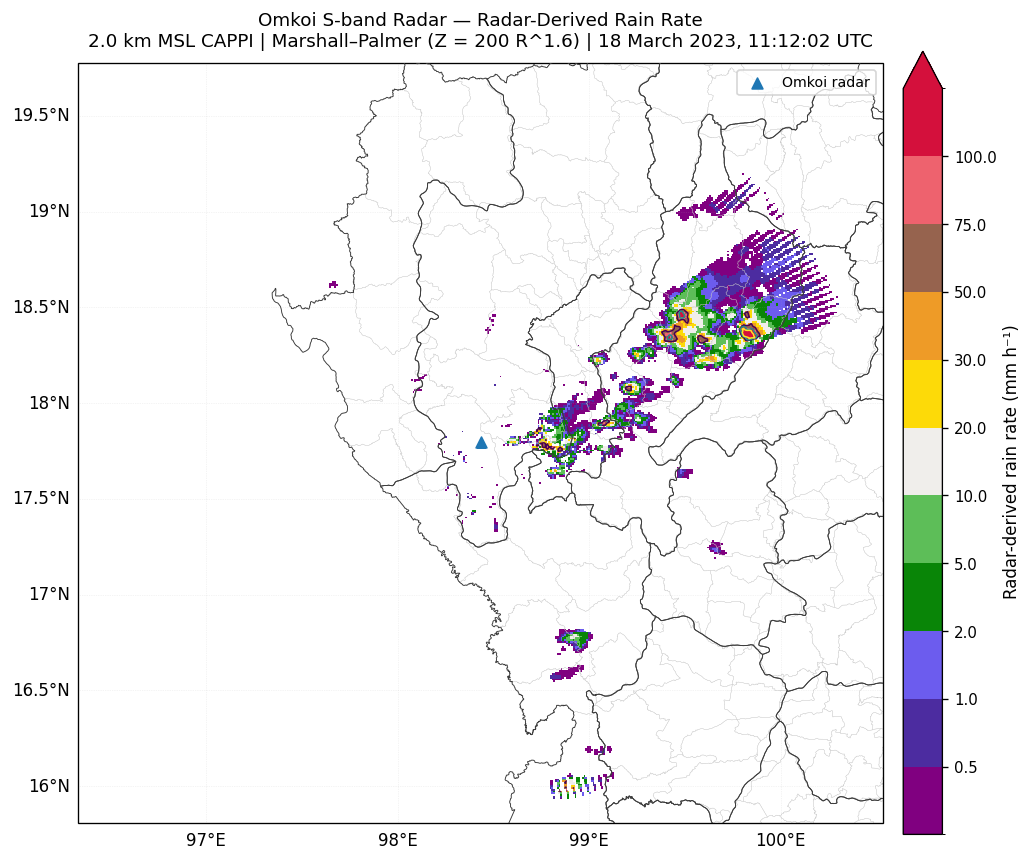

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_QPE_full_CONV_300_1.4_2.0kmMSL.png


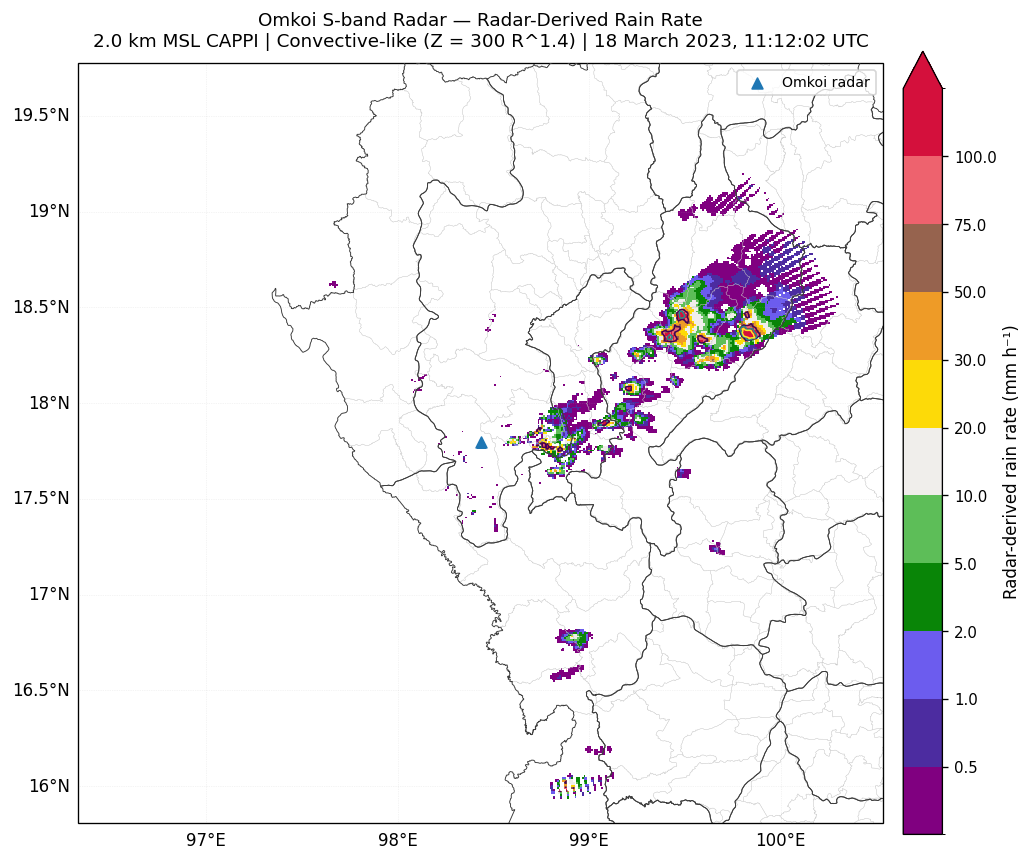

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_QPE_full_TROP_250_1.2_2.0kmMSL.png


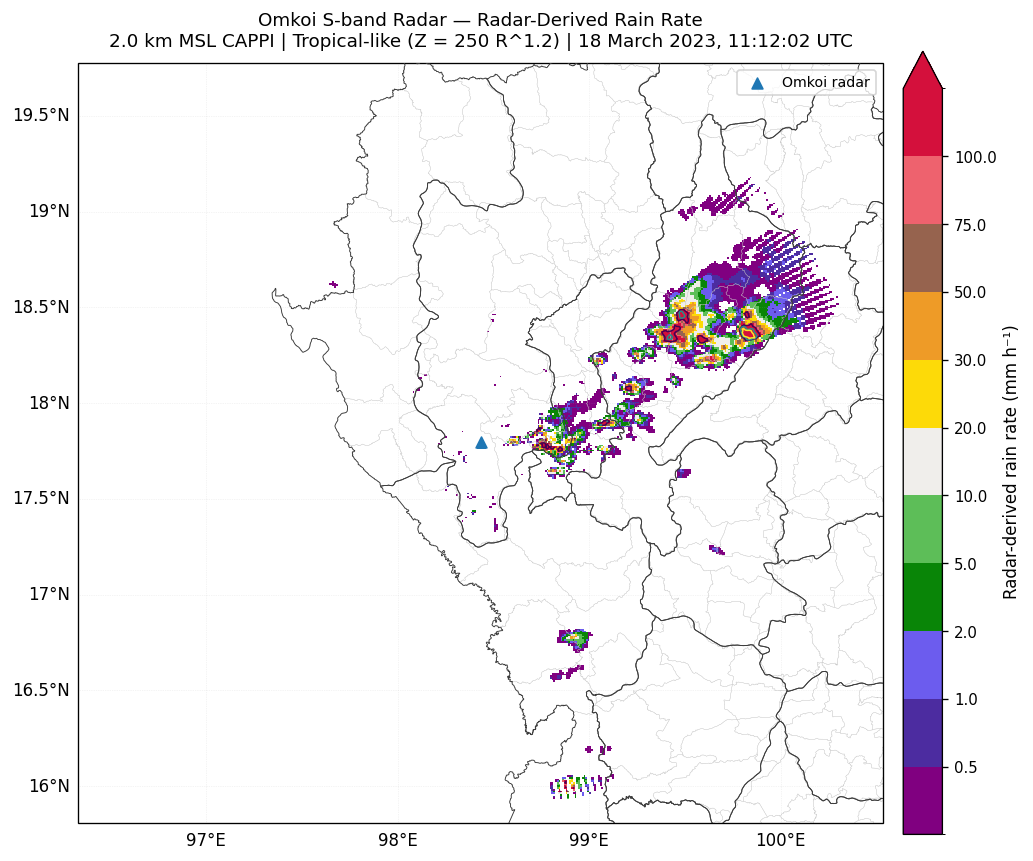

In [25]:
# CELL 25 — Export full-domain QPE maps

QPE_FULL_FIGURES = {}

for relation_id, rainfall in (
    RAIN_RATE_PRODUCTS.items()
):
    output_path = (
        FIGURE_DIR
        / (
            "04_QPE_full_"
            f"{relation_id}_"
            f"{QPE_ACTUAL_HEIGHT_KM_MSL:.1f}kmMSL.png"
        )
    )

    plot_qpe_geographic(
        rainfall,
        relation_id=(
            relation_id
        ),
        output_path=(
            output_path
        ),
    )

    QPE_FULL_FIGURES[
        relation_id
    ] = output_path

# 19. Storm-focused QPE maps

Full-domain map เหมาะกับ spatial context

แต่สำหรับ hail-producing convective core เราต้องเห็นรายละเอียดบริเวณ storm ROI โดยไม่มี:

- range-ring labels
- GIS clutter มากเกินไป
- title ที่ยาวเกินจำเป็น

Storm-focused figures ใช้ Cartesian x/y จาก radar เป็นหลัก เพื่อเน้น physics และ relation sensitivity

In [26]:
# CELL 26 — Storm-focused QPE plotting helper

def plot_qpe_storm_focus(
    rainfall,
    *,
    relation_id,
    output_path,
):
    rain = np.ma.asarray(
        rainfall
    )

    rain_sub = rain[
        np.ix_(
            y_roi_mask,
            x_roi_mask,
        )
    ]

    zh_sub = ZH_CAPPI[
        np.ix_(
            y_roi_mask,
            x_roi_mask,
        )
    ]

    x_sub = grid_x_km[
        x_roi_mask
    ]

    y_sub = grid_y_km[
        y_roi_mask
    ]

    display_rain = np.ma.masked_less(
        rain_sub,
        RAIN_RATE_BOUNDS_MMH[
            0
        ],
    )

    fig = plt.figure(
        figsize=(
            7.8,
            6.6,
        )
    )

    ax = fig.add_subplot(
        111
    )

    mesh = ax.pcolormesh(
        x_sub,
        y_sub,
        display_rain,
        shading="auto",
        cmap=RAIN_CMAP,
        norm=RAIN_NORM,
        rasterized=True,
    )

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.90,
        boundaries=(
            RAIN_RATE_BOUNDS_MMH
        ),
        ticks=(
            RAIN_RATE_BOUNDS_MMH[
                1:-1
            ]
        ),
        extend="max",
    )

    cbar.set_label(
        "Radar-derived rain rate (mm h⁻¹)"
    )

    zh_values_sub = (
        zh_sub.filled(
            np.nan
        )
    )

    finite_zh = zh_values_sub[
        np.isfinite(
            zh_values_sub
        )
    ]

    if finite_zh.size:
        levels = [
            level
            for level in (
                HAIL_CAUTION_LEVELS_DBZ
            )
            if (
                np.nanmin(
                    finite_zh
                )
                <= level
                <= np.nanmax(
                    finite_zh
                )
            )
        ]

        if levels:
            contours = ax.contour(
                x_sub,
                y_sub,
                zh_values_sub,
                levels=levels,
                linewidths=1.0,
            )

            ax.clabel(
                contours,
                fmt=lambda value: (
                    f"{value:.0f} dBZ"
                ),
                fontsize=7,
                inline=True,
            )

    ax.set_xlim(
        roi_xmin_km,
        roi_xmax_km,
    )

    ax.set_ylim(
        roi_ymin_km,
        roi_ymax_km,
    )

    ax.set_xlabel(
        "East–west distance from radar (km)"
    )

    ax.set_ylabel(
        "North–south distance from radar (km)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    relation = (
        ZR_RELATIONS[
            relation_id
        ]
    )

    ax.set_title(
        (
            "Observed-Hail Event — Storm-Focused Radar-Derived Rain Rate\n"
            f"{relation['label']} | "
            f"{QPE_ACTUAL_HEIGHT_KM_MSL:.1f} km MSL | "
            f"{observation_time_UTC.strftime('%H:%M:%S UTC')}"
        )
    )

    ax.grid(
        alpha=0.16,
        linestyle=":",
    )

    save_figure(
        fig,
        output_path,
        source_file=selected_filename,
        product="storm-focused radar-derived rain rate",
        relation_id=relation_id,
        CAPPI_height_km_MSL=(
            QPE_ACTUAL_HEIGHT_KM_MSL
        ),
        processing=(
            "Storm ROI from Notebook 02; "
            "no upper reflectivity clipping; "
            "50/55/60-dBZ contours are caution context."
        ),
        units="mm h-1",
        time_UTC=str(
            observation_time_UTC
        ),
        colormap=RAIN_CMAP_NAME,
    )

    plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_QPE_storm_MP_200_1.6_2.0kmMSL.png


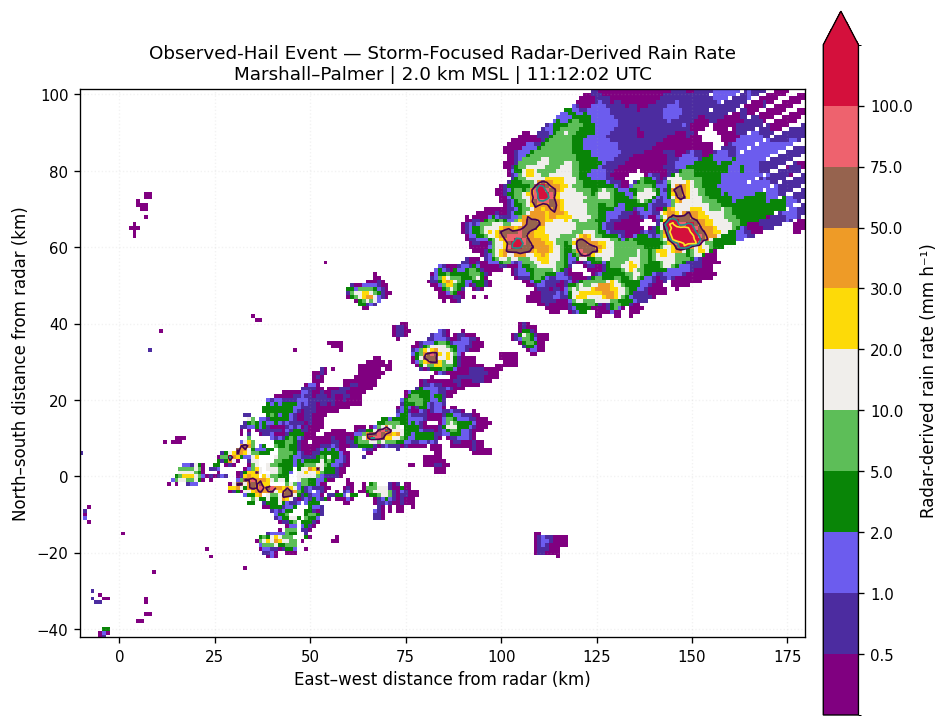

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_QPE_storm_CONV_300_1.4_2.0kmMSL.png


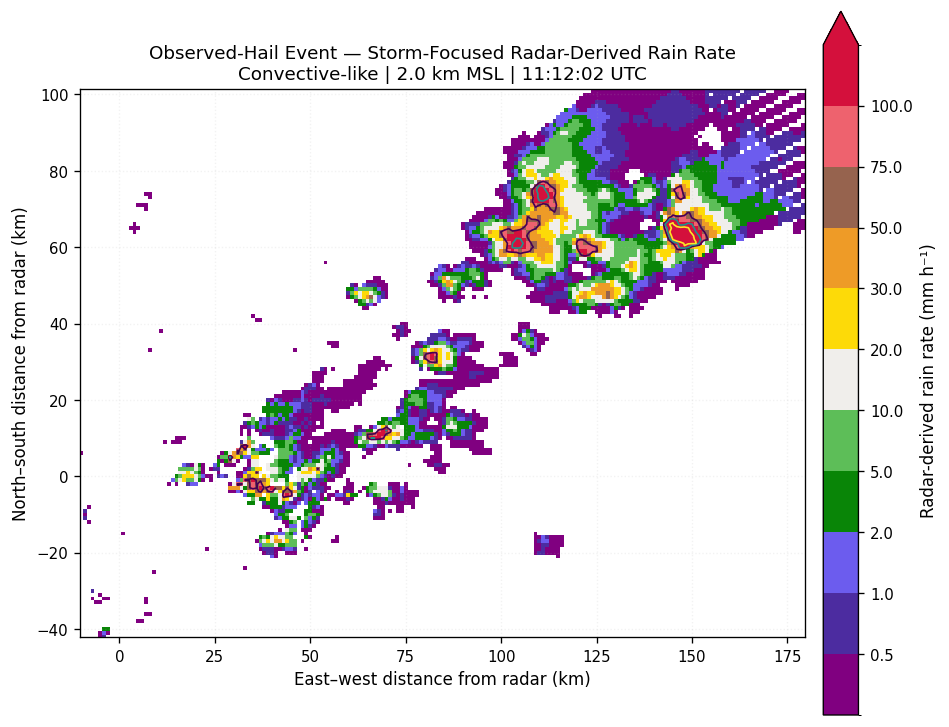

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_QPE_storm_TROP_250_1.2_2.0kmMSL.png


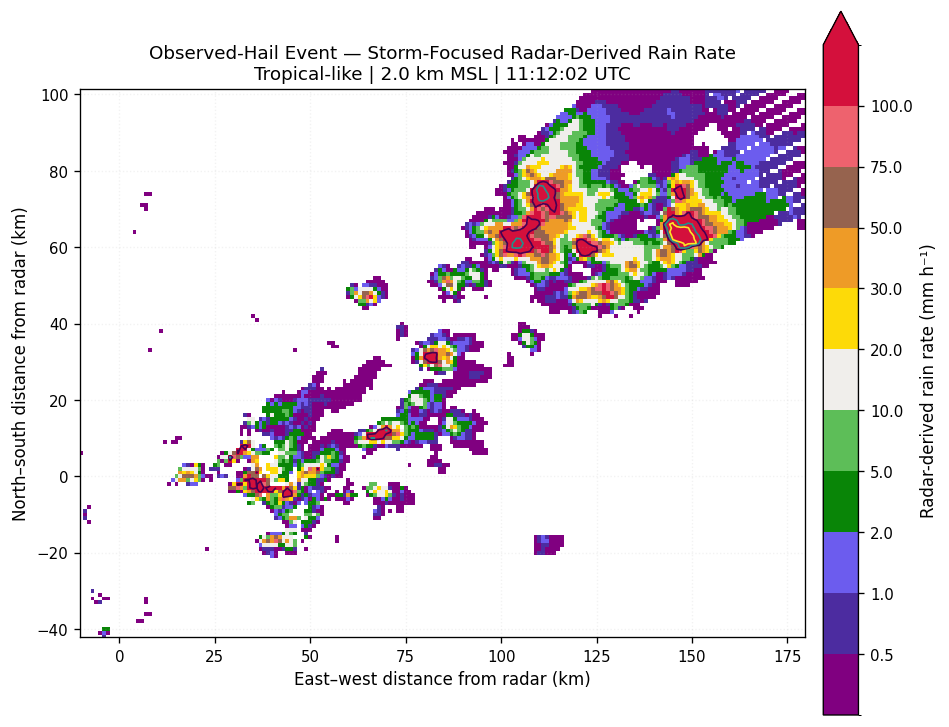

In [27]:
# CELL 27 — Export storm-focused QPE maps

QPE_STORM_FIGURES = {}

for relation_id, rainfall in (
    RAIN_RATE_PRODUCTS.items()
):
    output_path = (
        FIGURE_DIR
        / (
            "04_QPE_storm_"
            f"{relation_id}_"
            f"{QPE_ACTUAL_HEIGHT_KM_MSL:.1f}kmMSL.png"
        )
    )

    plot_qpe_storm_focus(
        rainfall,
        relation_id=(
            relation_id
        ),
        output_path=(
            output_path
        ),
    )

    QPE_STORM_FIGURES[
        relation_id
    ] = output_path

# 20. Z–R sensitivity: difference maps

การเปรียบเทียบ Z–R relations ควรใช้ pixel เดียวกันและ support เดียวกัน

กำหนด Marshall–Palmer เป็น baseline:

\[
\Delta R =
R_{alternative}
-
R_{MP}
\]

ค่าบวกหมายถึง alternative relation ให้ estimated rain rate สูงกว่า baseline

ค่าลบหมายถึงต่ำกว่า

นี่เป็น **method sensitivity** ไม่ใช่ error เพราะยังไม่มี gauge truth

In [28]:
# CELL 28 — Difference products relative to baseline

BASE_RAIN = np.ma.asarray(
    RAIN_RATE_PRODUCTS[
        BASE_RELATION
    ]
)

QPE_DIFFERENCE_PRODUCTS = {}

for relation_id in (
    RELATION_IDS
):
    if relation_id == (
        BASE_RELATION
    ):
        continue

    alternative = np.ma.asarray(
        RAIN_RATE_PRODUCTS[
            relation_id
        ]
    )

    common_mask = (
        np.ma.getmaskarray(
            BASE_RAIN
        )
        | np.ma.getmaskarray(
            alternative
        )
    )

    difference = np.ma.array(
        alternative
        - BASE_RAIN,
        mask=(
            common_mask
        ),
    )

    QPE_DIFFERENCE_PRODUCTS[
        relation_id
    ] = difference

In [29]:
# CELL 29 — Difference-map helper

def plot_qpe_difference(
    difference,
    *,
    relation_id,
    output_path,
):
    diff_sub = np.ma.asarray(
        difference
    )[
        np.ix_(
            y_roi_mask,
            x_roi_mask,
        )
    ]

    x_sub = grid_x_km[
        x_roi_mask
    ]

    y_sub = grid_y_km[
        y_roi_mask
    ]

    diff_values = diff_sub.compressed()

    if diff_values.size:
        limit = float(
            np.nanpercentile(
                np.abs(
                    diff_values
                ),
                98,
            )
        )

        limit = min(
            max(
                limit,
                5.0,
            ),
            DIFFERENCE_DISPLAY_LIMIT_MMH,
        )

    else:
        limit = 10.0

    fig = plt.figure(
        figsize=(
            7.7,
            6.4,
        )
    )

    ax = fig.add_subplot(
        111
    )

    mesh = ax.pcolormesh(
        x_sub,
        y_sub,
        diff_sub,
        shading="auto",
        cmap="RdBu_r",
        norm=TwoSlopeNorm(
            vmin=(
                -limit
            ),
            vcenter=0.0,
            vmax=limit,
        ),
        rasterized=True,
    )

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.90,
        extend="both",
    )

    cbar.set_label(
        "Rain-rate difference from Marshall–Palmer (mm h⁻¹)"
    )

    ax.set_xlabel(
        "East–west distance from radar (km)"
    )

    ax.set_ylabel(
        "North–south distance from radar (km)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    relation = (
        ZR_RELATIONS[
            relation_id
        ]
    )

    ax.set_title(
        (
            "Z–R Sensitivity Relative to Marshall–Palmer\n"
            f"{relation['label']} minus Marshall–Palmer | "
            f"{QPE_ACTUAL_HEIGHT_KM_MSL:.1f} km MSL"
        )
    )

    ax.grid(
        alpha=0.16,
        linestyle=":",
    )

    save_figure(
        fig,
        output_path,
        source_file=selected_filename,
        product="Z-R sensitivity difference",
        relation_id=relation_id,
        baseline_relation=(
            BASE_RELATION
        ),
        processing=(
            "Alternative Z-R rain rate minus Marshall-Palmer "
            "on common valid pixels."
        ),
        units="mm h-1",
        time_UTC=str(
            observation_time_UTC
        ),
    )

    plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_QPE_difference_CONV_300_1.4_minus_MP_200_1.6.png


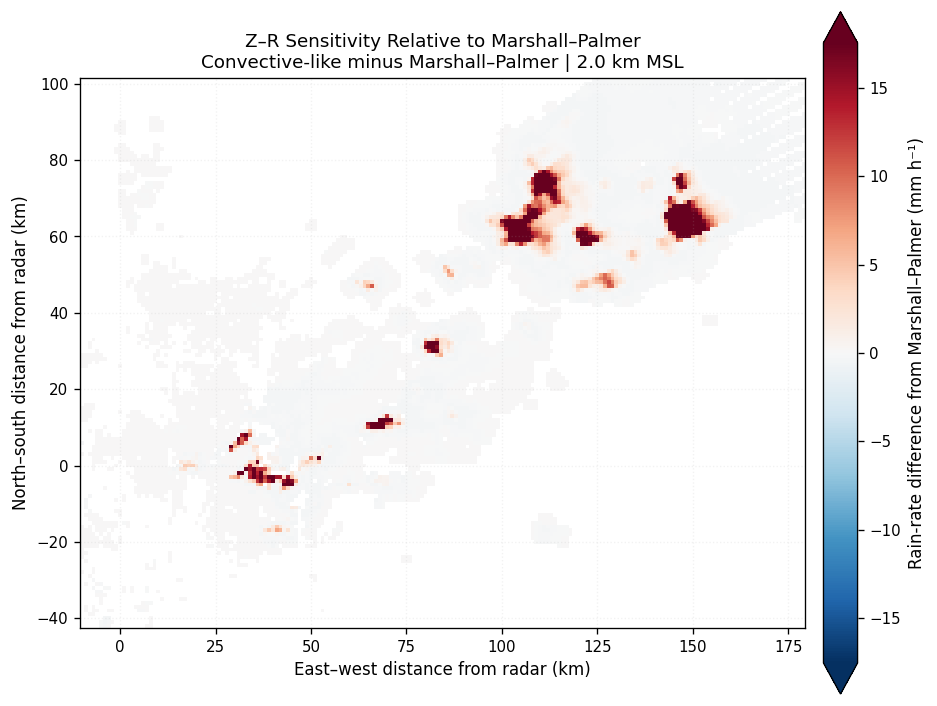

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_QPE_difference_TROP_250_1.2_minus_MP_200_1.6.png


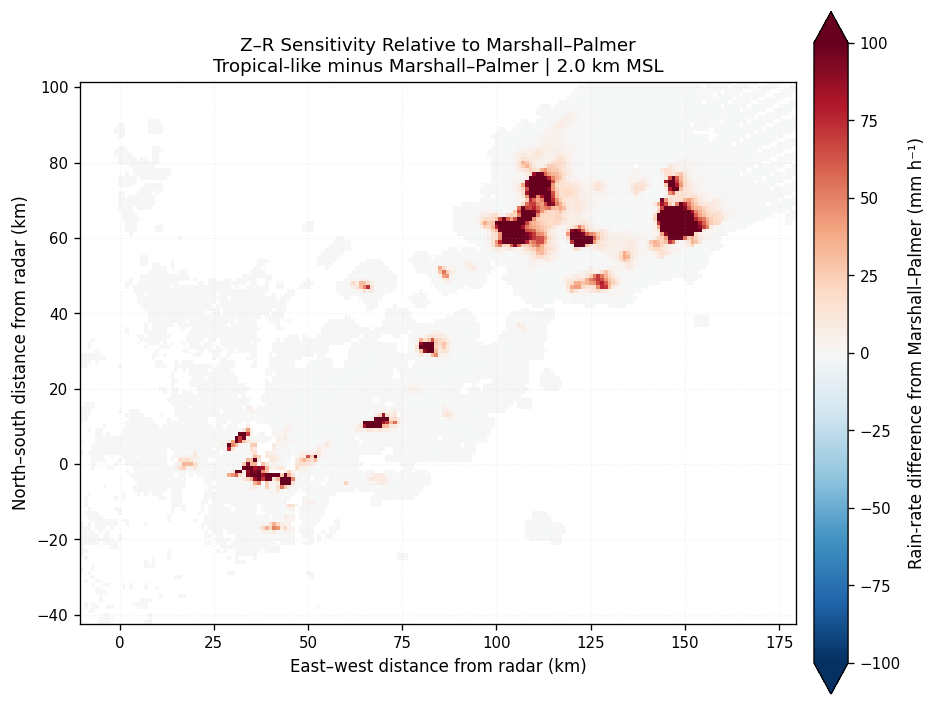

In [30]:
# CELL 30 — Export Z–R difference maps

QPE_DIFFERENCE_FIGURES = {}

for relation_id, difference in (
    QPE_DIFFERENCE_PRODUCTS.items()
):
    output_path = (
        FIGURE_DIR
        / (
            "04_QPE_difference_"
            f"{relation_id}_minus_"
            f"{BASE_RELATION}.png"
        )
    )

    plot_qpe_difference(
        difference,
        relation_id=(
            relation_id
        ),
        output_path=(
            output_path
        ),
    )

    QPE_DIFFERENCE_FIGURES[
        relation_id
    ] = output_path

# 21. Distribution comparison

Rain-rate values จาก convective storm มักมี long tail

ดังนั้นใช้ logarithmic x-axis เพื่อให้เห็นทั้ง:

- light rain
- moderate rain
- intense values
- extreme Z–R estimates

High-end tail ใน observed-hail event ต้องตีความอย่างระมัดระวังเป็นพิเศษ

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_fig08_QPE_distribution_sensitivity.png


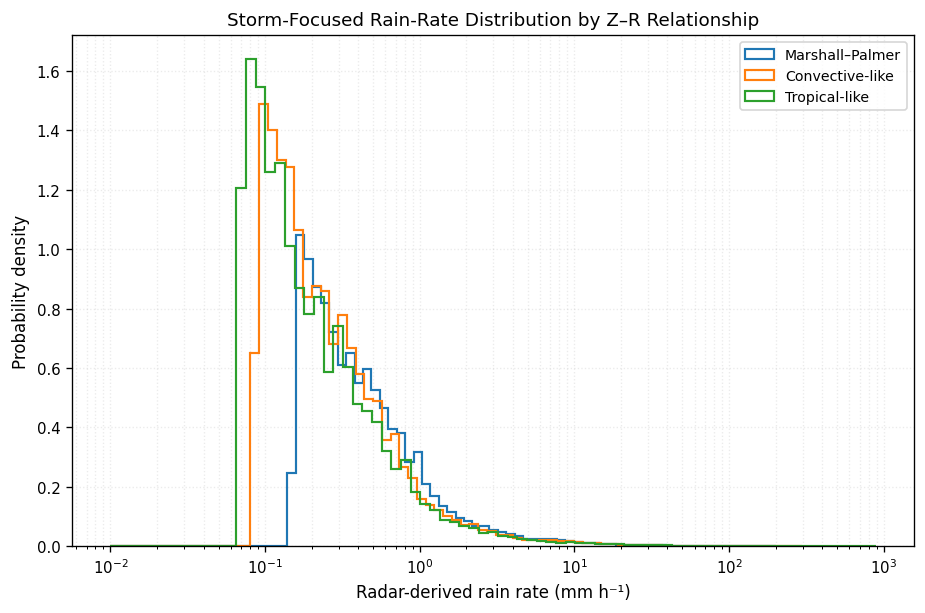

In [31]:
# CELL 31 — Storm-ROI rain-rate distributions

fig = plt.figure(
    figsize=(
        7.6,
        5.0,
    )
)

ax = fig.add_subplot(
    111
)

for relation_id, rainfall in (
    RAIN_RATE_PRODUCTS.items()
):
    rain_sub = np.ma.asarray(
        rainfall
    )[
        np.ix_(
            y_roi_mask,
            x_roi_mask,
        )
    ]

    values = rain_sub.compressed()

    values = values[
        np.isfinite(
            values
        )
        & (
            values
            > 0.0
        )
    ]

    if values.size == 0:
        continue

    max_hist = max(
        200.0,
        float(
            np.nanpercentile(
                values,
                99.5,
            )
        ),
    )

    bins = np.logspace(
        -2,
        np.log10(
            max_hist
        ),
        80,
    )

    ax.hist(
        values,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.3,
        label=(
            ZR_RELATIONS[
                relation_id
            ][
                "label"
            ]
        ),
    )

ax.set_xscale(
    "log"
)

ax.set_xlabel(
    "Radar-derived rain rate (mm h⁻¹)"
)

ax.set_ylabel(
    "Probability density"
)

ax.set_title(
    "Storm-Focused Rain-Rate Distribution by Z–R Relationship"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
    which="both",
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "04_fig08_QPE_distribution_sensitivity.png"
)

save_figure(
    fig,
    F,
    source_file=selected_filename,
    product="QPE distribution sensitivity",
    processing=(
        "Positive storm-ROI rain-rate pixels; "
        "comparison among Z-R relations."
    ),
    units="mm h-1",
    time_UTC=str(
        observation_time_UTC
    ),
)

plt.show()

# 22. ทฤษฎีการสกัดค่าตามตำแหน่ง

เมื่อมี Cartesian grid แล้ว เราสามารถถามว่า:

> ที่พิกัดนี้ estimated rain rate เท่าใด?

แต่ต้องแยกอย่างน้อย 3 แนวคิด:

### 1. Requested point

พิกัดที่ผู้ใช้กำหนด เช่น:

```text
longitude / latitude
UTM easting / northing
```

### 2. Nearest Cartesian grid cell

ค่าที่สกัดจาก CAPPI grid

### 3. Nearest native radar gate

ค่าจาก original polar observation

สองอย่างหลังไม่เหมือนกัน เพราะ:

- อยู่คนละ geometry
- CAPPI ผ่าน interpolation
- native gate มี beam height ตาม range/elevation
- nearest native gate อาจไม่ได้อยู่ที่ 2 km MSL

ดังนั้นการสกัดค่าต้องบอกเสมอว่าใช้:

```text
native gate
หรือ
Cartesian grid cell
```

# 23. จุดตัวอย่างของ Notebook นี้

ค่า default คือ:

```text
POINT_MODE = "strong_echo_reference"
```

จุดตัวอย่างจะถูกคำนวณจาก:

- median strong-echo range
- median strong-echo azimuth

ที่ Notebook 02 ตรวจไว้

เหตุผลคือใช้เป็นตัวอย่าง teaching point ที่อยู่ใกล้ main hail-producing convective complex

นิสิตสามารถเปลี่ยนเป็น:

```python
POINT_MODE = "manual"
MANUAL_POINT_LON = ...
MANUAL_POINT_LAT = ...
```

ได้ใน parameter block

In [32]:
# CELL 32 — Strong-echo reference point in lon/lat

MEDIAN_CORE_AZIMUTH_DEG = float(
    grid_config_lookup[
        "strong_echo_reference_azimuth_deg"
    ]
)

MEDIAN_CORE_RANGE_KM = float(
    grid_config_lookup[
        "strong_echo_reference_range_km"
    ]
)

core_x_m = (
    MEDIAN_CORE_RANGE_KM
    * 1000.0
    * np.sin(
        np.deg2rad(
            MEDIAN_CORE_AZIMUTH_DEG
        )
    )
)

core_y_m = (
    MEDIAN_CORE_RANGE_KM
    * 1000.0
    * np.cos(
        np.deg2rad(
            MEDIAN_CORE_AZIMUTH_DEG
        )
    )
)

core_lon, core_lat = (
    pyart.core.cartesian_to_geographic_aeqd(
        np.array(
            [
                core_x_m
            ]
        ),
        np.array(
            [
                core_y_m
            ]
        ),
        radar_lon,
        radar_lat,
    )
)

CORE_POINT_LON = float(
    core_lon[
        0
    ]
)

CORE_POINT_LAT = float(
    core_lat[
        0
    ]
)


if POINT_MODE == (
    "strong_echo_reference"
):
    POINT_LON = (
        CORE_POINT_LON
    )

    POINT_LAT = (
        CORE_POINT_LAT
    )

elif POINT_MODE == (
    "manual"
):
    if (
        MANUAL_POINT_LON
        is None
        or MANUAL_POINT_LAT
        is None
    ):
        raise ValueError(
            "POINT_MODE='manual' แต่ยังไม่ได้กำหนด MANUAL_POINT_LON/LAT"
        )

    POINT_LON = float(
        MANUAL_POINT_LON
    )

    POINT_LAT = float(
        MANUAL_POINT_LAT
    )

else:
    raise ValueError(
        "POINT_MODE ต้องเป็น 'strong_echo_reference' หรือ 'manual'"
    )


print(
    "Point mode:",
    POINT_MODE,
)

print(
    "Longitude:",
    POINT_LON,
)

print(
    "Latitude:",
    POINT_LAT,
)

Point mode: strong_echo_reference
Longitude: 99.31371291095486
Latitude: 18.030633492917154


In [33]:
# CELL 33 — Nearest Cartesian grid-cell extractor

GEOD = Geod(
    ellps="WGS84"
)


def extract_nearest_grid_cell(
    array_2d,
    *,
    longitude,
    latitude,
):
    distance2 = (
        (
            grid_lon
            - longitude
        )**2
        + (
            grid_lat
            - latitude
        )**2
    )

    flat_index = int(
        np.nanargmin(
            distance2
        )
    )

    iy, ix = np.unravel_index(
        flat_index,
        distance2.shape,
    )

    grid_cell_lon = float(
        grid_lon[
            iy,
            ix
        ]
    )

    grid_cell_lat = float(
        grid_lat[
            iy,
            ix
        ]
    )

    _, _, distance_m = (
        GEOD.inv(
            longitude,
            latitude,
            grid_cell_lon,
            grid_cell_lat,
        )
    )

    value = np.ma.asarray(
        array_2d
    )[
        iy,
        ix
    ]

    return {
        "iy": (
            iy
        ),
        "ix": (
            ix
        ),
        "requested_lon": (
            longitude
        ),
        "requested_lat": (
            latitude
        ),
        "grid_lon": (
            grid_cell_lon
        ),
        "grid_lat": (
            grid_cell_lat
        ),
        "distance_to_grid_center_m": float(
            distance_m
        ),
        "value": (
            float(
                value
            )
            if not np.ma.is_masked(
                value
            )
            else np.nan
        ),
    }

In [34]:
# CELL 34 — Extract reflectivity and rain rate at the teaching point

point_zh = (
    extract_nearest_grid_cell(
        ZH_CAPPI,
        longitude=(
            POINT_LON
        ),
        latitude=(
            POINT_LAT
        ),
    )
)

point_rows = []

for relation_id, rainfall in (
    RAIN_RATE_PRODUCTS.items()
):
    extracted = (
        extract_nearest_grid_cell(
            rainfall,
            longitude=(
                POINT_LON
            ),
            latitude=(
                POINT_LAT
            ),
        )
    )

    point_rows.append({
        "point_mode": (
            POINT_MODE
        ),
        "requested_lon": (
            POINT_LON
        ),
        "requested_lat": (
            POINT_LAT
        ),
        "grid_lon": (
            extracted[
                "grid_lon"
            ]
        ),
        "grid_lat": (
            extracted[
                "grid_lat"
            ]
        ),
        "distance_to_grid_center_m": (
            extracted[
                "distance_to_grid_center_m"
            ]
        ),
        "CAPPI_height_km_MSL": (
            QPE_ACTUAL_HEIGHT_KM_MSL
        ),
        "corrected_ZH_dBZ": (
            point_zh[
                "value"
            ]
        ),
        "hail_caution_ge_50dBZ": (
            bool(
                np.isfinite(
                    point_zh[
                        "value"
                    ]
                )
                and (
                    point_zh[
                        "value"
                    ]
                    >= 50.0
                )
            )
        ),
        "relation_id": (
            relation_id
        ),
        "relation_label": (
            ZR_RELATIONS[
                relation_id
            ][
                "label"
            ]
        ),
        "rain_rate_mmh": (
            extracted[
                "value"
            ]
        ),
    })


POINT_EXTRACTION = pd.DataFrame(
    point_rows
)

display(
    POINT_EXTRACTION
)

POINT_EXTRACTION_CSV = (
    OUTPUT_CSV_DIR
    / "04_point_extraction.csv"
)

POINT_EXTRACTION.to_csv(
    POINT_EXTRACTION_CSV,
    index=False,
)

,point_mode,requested_lon,requested_lat,grid_lon,grid_lat,distance_to_grid_center_m,CAPPI_height_km_MSL,corrected_ZH_dBZ,hail_caution_ge_50dBZ,relation_id,relation_label,rain_rate_mmh
0,strong_echo_reference,99.313713,18.030633,99.311888,18.030061,203.346084,2.0,20.758682,False,MP_200_1.6,Marshall–Palmer,0.723226
1,strong_echo_reference,99.313713,18.030633,99.311888,18.030061,203.346084,2.0,20.758682,False,CONV_300_1.4,Convective-like,0.516881
2,strong_echo_reference,99.313713,18.030633,99.311888,18.030061,203.346084,2.0,20.758682,False,TROP_250_1.2,Tropical-like,0.539022


# 24. UTM point extraction

สำหรับงาน GIS ในประเทศไทย พิกัด projected coordinate มีประโยชน์มาก โดยเฉพาะ:

- field survey
- administrative analysis
- distance measurement
- integration กับ GIS layers

Notebook จะ derive UTM zone จาก radar location อัตโนมัติ

Omkoi ควรอยู่:

```text
UTM Zone 47N
EPSG:32647
```

แต่ code จะไม่ hard-code zone

In [35]:
# CELL 35 — Automatic UTM CRS and point coordinate

def utm_from_lon_lat(
    lon,
    lat,
):
    zone = int(
        np.floor(
            (
                lon
                + 180.0
            )
            / 6.0
        )
        + 1
    )

    if lat >= 0:
        epsg = (
            32600
            + zone
        )

        hemisphere = (
            "N"
        )

    else:
        epsg = (
            32700
            + zone
        )

        hemisphere = (
            "S"
        )

    return {
        "zone": (
            zone
        ),
        "hemisphere": (
            hemisphere
        ),
        "epsg": (
            epsg
        ),
        "crs": CRS.from_epsg(
            epsg
        ),
    }


UTM_INFO = (
    utm_from_lon_lat(
        radar_lon,
        radar_lat,
    )
)

to_utm = Transformer.from_crs(
    "EPSG:4326",
    UTM_INFO[
        "crs"
    ],
    always_xy=True,
)

to_wgs84 = Transformer.from_crs(
    UTM_INFO[
        "crs"
    ],
    "EPSG:4326",
    always_xy=True,
)

POINT_EASTING_M, POINT_NORTHING_M = (
    to_utm.transform(
        POINT_LON,
        POINT_LAT,
    )
)

print(
    "UTM:",
    f"{UTM_INFO['zone']}"
    f"{UTM_INFO['hemisphere']}",
)

print(
    "EPSG:",
    UTM_INFO[
        "epsg"
    ],
)

print(
    "Point easting:",
    POINT_EASTING_M,
)

print(
    "Point northing:",
    POINT_NORTHING_M,
)

UTM: 47N
EPSG: 32647
Point easting: 533204.8668542323
Point northing: 1993602.8553509044


In [36]:
# CELL 36 — Verify extraction using UTM → lon/lat round trip

point_lon_from_utm, point_lat_from_utm = (
    to_wgs84.transform(
        POINT_EASTING_M,
        POINT_NORTHING_M,
    )
)

utm_roundtrip_point = (
    extract_nearest_grid_cell(
        ZH_CAPPI,
        longitude=(
            point_lon_from_utm
        ),
        latitude=(
            point_lat_from_utm
        ),
    )
)

UTM_POINT_CHECK = pd.DataFrame({
    "parameter": [
        "UTM_zone",
        "UTM_EPSG",
        "easting_m",
        "northing_m",
        "roundtrip_lon",
        "roundtrip_lat",
        "grid_ZH_dBZ_from_roundtrip",
        "lon_error_deg",
        "lat_error_deg",
    ],
    "value": [
        (
            f"{UTM_INFO['zone']}"
            f"{UTM_INFO['hemisphere']}"
        ),
        UTM_INFO[
            "epsg"
        ],
        POINT_EASTING_M,
        POINT_NORTHING_M,
        point_lon_from_utm,
        point_lat_from_utm,
        utm_roundtrip_point[
            "value"
        ],
        point_lon_from_utm
        - POINT_LON,
        point_lat_from_utm
        - POINT_LAT,
    ],
})

display(
    UTM_POINT_CHECK
)

,parameter,value
0,UTM_zone,47N
1,UTM_EPSG,32647
2,easting_m,533204.866854
3,northing_m,1993602.855351
4,roundtrip_lon,99.313713
5,roundtrip_lat,18.030633
6,grid_ZH_dBZ_from_roundtrip,20.758682
7,lon_error_deg,0.0
8,lat_error_deg,0.0


# 25. ADVANCED — เปรียบเทียบ CAPPI grid cell กับ nearest native radar gate

CAPPI ที่ 2 km MSL ผ่าน Cartesian interpolation แล้ว

เพื่อให้นิสิตเห็นความต่างของ representation จะอ่าน UF ต้นฉบับของ peak volume และหา nearest gate ใน **lowest sweep**

เปรียบเทียบ:

```text
CAPPI grid-cell ZH
vs
nearest native 0.5° gate ZH
```

พร้อมรายงาน native gate altitude MSL

หากค่าต่างกัน ไม่ควรสรุปทันทีว่าอันใด “ผิด”

เพราะทั้งสองเป็นคนละ sampling geometry

In [37]:
# CELL 37 — Robust radar reader for native-gate comparison

RADAR_CACHE = (
    Path(
        tempfile.gettempdir()
    )
    / "drraa_radar_uf_cache"
)

RADAR_CACHE.mkdir(
    parents=True,
    exist_ok=True,
)


def read_radar_file(
    path,
):
    path = Path(
        path
    )

    try:
        return pyart.io.read(
            str(
                path
            )
        )

    except Exception as direct_error:

        if path.suffix.lower() != ".gz":
            raise

        unpacked = (
            RADAR_CACHE
            / path.with_suffix(
                ""
            ).name
        )

        if not unpacked.exists():
            with gzip.open(
                path,
                "rb",
            ) as source, unpacked.open(
                "wb"
            ) as target:
                shutil.copyfileobj(
                    source,
                    target,
                )

        try:
            return pyart.io.read(
                str(
                    unpacked
                )
            )

        except Exception as unpacked_error:
            raise RuntimeError(
                f"อ่านไฟล์ {path.name} ไม่สำเร็จ "
                f"(compressed={direct_error!r}; "
                f"unpacked={unpacked_error!r})"
            ) from unpacked_error

In [38]:
# CELL 38 — Nearest native lowest-sweep gate

native_radar = read_radar_file(
    RADAR_DIR
    / selected_filename
)

NATIVE_SWEEP = 0

start_ray = int(
    native_radar.sweep_start_ray_index[
        "data"
    ][
        NATIVE_SWEEP
    ]
)

end_ray = int(
    native_radar.sweep_end_ray_index[
        "data"
    ][
        NATIVE_SWEEP
    ]
)

gate_x_m = np.asarray(
    native_radar.gate_x[
        "data"
    ][
        start_ray:
        end_ray
        + 1
    ],
    dtype=float,
)

gate_y_m = np.asarray(
    native_radar.gate_y[
        "data"
    ][
        start_ray:
        end_ray
        + 1
    ],
    dtype=float,
)

gate_z_m_ARL = np.asarray(
    native_radar.gate_z[
        "data"
    ][
        start_ray:
        end_ray
        + 1
    ],
    dtype=float,
)

gate_lon, gate_lat = (
    pyart.core.cartesian_to_geographic_aeqd(
        gate_x_m,
        gate_y_m,
        radar_lon,
        radar_lat,
    )
)

distance2 = (
    (
        gate_lon
        - POINT_LON
    )**2
    + (
        gate_lat
        - POINT_LAT
    )**2
)

flat_gate = int(
    np.nanargmin(
        distance2
    )
)

ray_local, gate_index = (
    np.unravel_index(
        flat_gate,
        distance2.shape,
    )
)

native_gate_lon = float(
    gate_lon[
        ray_local,
        gate_index
    ]
)

native_gate_lat = float(
    gate_lat[
        ray_local,
        gate_index
    ]
)

_, _, native_gate_distance_to_point_m = (
    GEOD.inv(
        POINT_LON,
        POINT_LAT,
        native_gate_lon,
        native_gate_lat,
    )
)

native_gate_alt_m_MSL = float(
    radar_altitude_m_MSL
    + gate_z_m_ARL[
        ray_local,
        gate_index
    ]
)

native_zh_sweep = np.ma.asarray(
    native_radar.get_field(
        NATIVE_SWEEP,
        FIELD_Z,
        copy=True,
    )
)

native_zh_value = (
    native_zh_sweep[
        ray_local,
        gate_index
    ]
)

native_zh_value = (
    float(
        native_zh_value
    )
    if not np.ma.is_masked(
        native_zh_value
    )
    else np.nan
)


NATIVE_GATE_COMPARISON = pd.DataFrame({
    "quantity": [
        "requested_lon",
        "requested_lat",
        "CAPPI_grid_lon",
        "CAPPI_grid_lat",
        "CAPPI_height_km_MSL",
        "CAPPI_corrected_ZH_dBZ",
        "native_sweep",
        "native_elevation_deg",
        "native_gate_lon",
        "native_gate_lat",
        "native_gate_altitude_km_MSL",
        "native_gate_corrected_ZH_dBZ",
        "distance_requested_to_CAPPI_cell_m",
        "distance_requested_to_native_gate_m",
    ],
    "value": [
        POINT_LON,
        POINT_LAT,
        point_zh[
            "grid_lon"
        ],
        point_zh[
            "grid_lat"
        ],
        QPE_ACTUAL_HEIGHT_KM_MSL,
        point_zh[
            "value"
        ],
        NATIVE_SWEEP,
        float(
            native_radar.fixed_angle[
                "data"
            ][
                NATIVE_SWEEP
            ]
        ),
        native_gate_lon,
        native_gate_lat,
        native_gate_alt_m_MSL
        / 1000.0,
        native_zh_value,
        point_zh[
            "distance_to_grid_center_m"
        ],
        float(
            native_gate_distance_to_point_m
        ),
    ],
})

display(
    NATIVE_GATE_COMPARISON
)

NATIVE_GATE_COMPARISON_CSV = (
    OUTPUT_CSV_DIR
    / "04_native_gate_vs_CAPPI_point.csv"
)

NATIVE_GATE_COMPARISON.to_csv(
    NATIVE_GATE_COMPARISON_CSV,
    index=False,
)

,quantity,value
0,requested_lon,99.313713
1,requested_lat,18.030633
2,CAPPI_grid_lon,99.311888
3,CAPPI_grid_lat,18.030061
4,CAPPI_height_km_MSL,2.000000
5,CAPPI_corrected_ZH_dBZ,20.758682
6,native_sweep,0.000000
7,native_elevation_deg,0.500000
8,native_gate_lon,99.311846
9,native_gate_lat,18.035796


# 26. Visualization ของ point extraction

Publication-ready point map ต้องแสดง:

- rain-rate field
- requested point
- nearest grid-cell center
- radar location
- administrative boundaries
- CAPPI height
- Z–R relation

ระยะ offset ระหว่าง requested point กับ grid-cell center ต้องถูก export เป็นตัวเลข ไม่ควรประเมินจากภาพอย่างเดียว

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_fig09_point_extraction_map.png


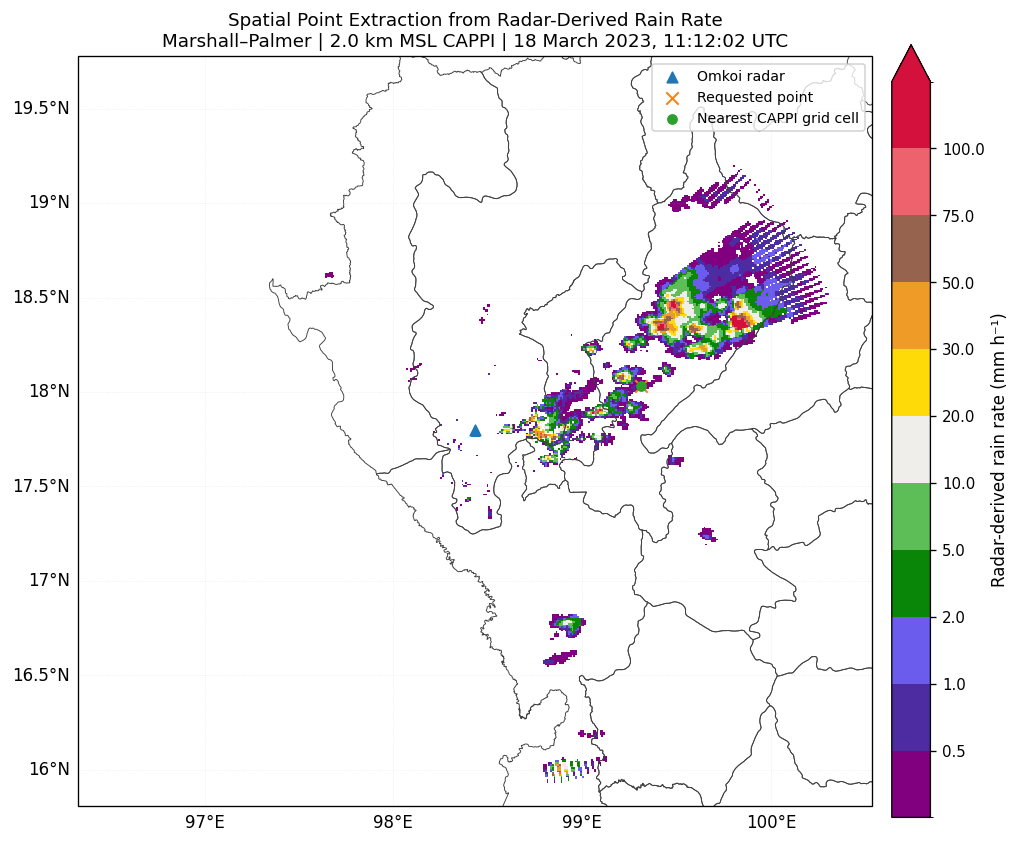

In [39]:
# CELL 39 — Point-extraction map using baseline Z–R relation

baseline_rain = (
    RAIN_RATE_PRODUCTS[
        BASE_RELATION
    ]
)

projection = (
    ccrs.PlateCarree()
)

fig = plt.figure(
    figsize=(
        8.4,
        7.4,
    )
)

ax = plt.axes(
    projection=projection
)

ax.set_extent(
    [
        lon_min,
        lon_max,
        lat_min,
        lat_max,
    ],
    crs=projection,
)

display_rain = np.ma.masked_less(
    baseline_rain,
    RAIN_RATE_BOUNDS_MMH[
        0
    ],
)

mesh = ax.pcolormesh(
    grid_lon,
    grid_lat,
    display_rain,
    transform=projection,
    shading="auto",
    cmap=RAIN_CMAP,
    norm=RAIN_NORM,
    rasterized=True,
    zorder=1,
)

for geom in (
    adm1_clip.geometry
):
    ax.add_geometries(
        [
            geom
        ],
        crs=projection,
        facecolor="none",
        edgecolor="0.25",
        linewidth=0.55,
        zorder=2,
    )

ax.scatter(
    radar_lon,
    radar_lat,
    transform=projection,
    marker="^",
    s=40,
    label="Omkoi radar",
    zorder=5,
)

ax.scatter(
    POINT_LON,
    POINT_LAT,
    transform=projection,
    marker="x",
    s=55,
    label="Requested point",
    zorder=6,
)

ax.scatter(
    point_zh[
        "grid_lon"
    ],
    point_zh[
        "grid_lat"
    ],
    transform=projection,
    marker="o",
    s=30,
    label="Nearest CAPPI grid cell",
    zorder=7,
)

gridliner = ax.gridlines(
    crs=projection,
    draw_labels=True,
    linewidth=0.40,
    alpha=0.30,
    linestyle=":",
)

gridliner.top_labels = False
gridliner.right_labels = False

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.88,
    boundaries=(
        RAIN_RATE_BOUNDS_MMH
    ),
    ticks=(
        RAIN_RATE_BOUNDS_MMH[
            1:-1
        ]
    ),
    extend="max",
)

cbar.set_label(
    "Radar-derived rain rate (mm h⁻¹)"
)

ax.set_title(
    (
        "Spatial Point Extraction from Radar-Derived Rain Rate\n"
        f"Marshall–Palmer | "
        f"{QPE_ACTUAL_HEIGHT_KM_MSL:.1f} km MSL CAPPI | "
        f"{observation_time_UTC.strftime('%d %B %Y, %H:%M:%S UTC')}"
    )
)

ax.legend(
    loc="upper right",
    frameon=True,
)

F = (
    FIGURE_DIR
    / "04_fig09_point_extraction_map.png"
)

save_figure(
    fig,
    F,
    source_file=selected_filename,
    product="QPE point extraction",
    relation_id=BASE_RELATION,
    CAPPI_height_km_MSL=(
        QPE_ACTUAL_HEIGHT_KM_MSL
    ),
    processing=(
        "Nearest Cartesian grid-cell extraction from baseline QPE."
    ),
    units="mm h-1",
    time_UTC=str(
        observation_time_UTC
    ),
)

plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_fig10_point_ZR_sensitivity.png


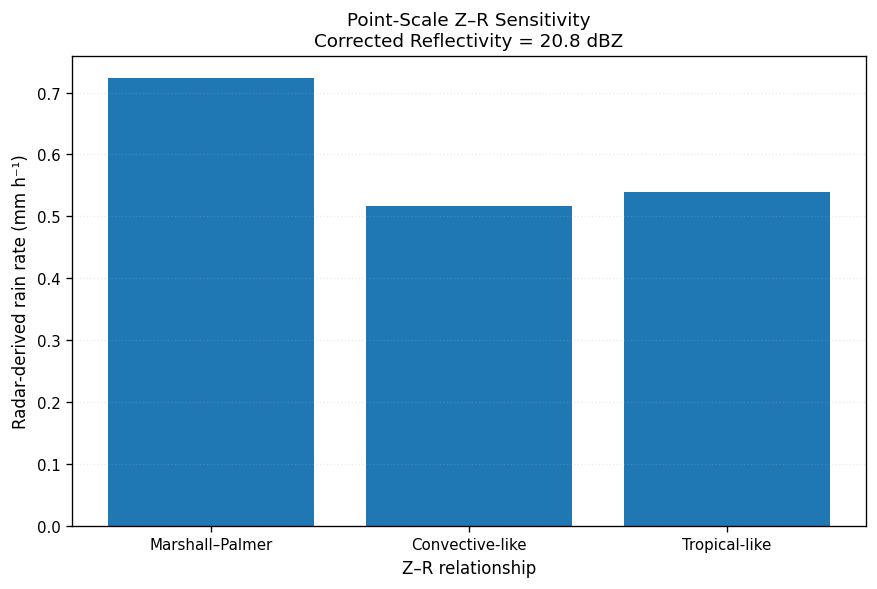

In [40]:
# CELL 40 — Point Z–R sensitivity figure

point_plot = (
    POINT_EXTRACTION[
        [
            "relation_label",
            "rain_rate_mmh",
        ]
    ]
    .copy()
)

fig = plt.figure(
    figsize=(
        7.2,
        4.8,
    )
)

ax = fig.add_subplot(
    111
)

ax.bar(
    point_plot[
        "relation_label"
    ],
    point_plot[
        "rain_rate_mmh"
    ],
)

ax.set_ylabel(
    "Radar-derived rain rate (mm h⁻¹)"
)

ax.set_xlabel(
    "Z–R relationship"
)

ax.set_title(
    (
        "Point-Scale Z–R Sensitivity\n"
        f"Corrected Reflectivity = "
        f"{point_zh['value']:.1f} dBZ"
        if np.isfinite(
            point_zh[
                "value"
            ]
        )
        else "Point-Scale Z–R Sensitivity"
    )
)

ax.grid(
    axis="y",
    alpha=0.25,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / "04_fig10_point_ZR_sensitivity.png"
)

save_figure(
    fig,
    F,
    source_file=selected_filename,
    product="point Z-R sensitivity",
    processing=(
        "Three Z-R relations evaluated at the same nearest CAPPI grid cell."
    ),
    units="mm h-1",
    time_UTC=str(
        observation_time_UTC
    ),
)

plt.show()

# 27. Quantitative Z–R sensitivity relative to baseline

Difference map ช่วยให้เห็น pattern แต่สำหรับงานวิจัยควรมี summary statistics ด้วย

สำหรับ alternative relation เทียบกับ Marshall–Palmer จะคำนวณ:

- common valid pixels
- mean difference
- median difference
- P05 / P95 difference
- maximum absolute difference
- median ratio \(R_{alt}/R_{MP}\) เฉพาะ wet common pixels
- P95 ratio

ค่านี้ยังเป็น **sensitivity metric** ไม่ใช่ validation error

In [41]:
# CELL 41 — Z–R sensitivity summary

sensitivity_rows = []

base_values = (
    BASE_RAIN.filled(
        np.nan
    )
)

for relation_id, difference in (
    QPE_DIFFERENCE_PRODUCTS.items()
):
    alt = np.ma.asarray(
        RAIN_RATE_PRODUCTS[
            relation_id
        ]
    )

    alt_values = alt.filled(
        np.nan
    )

    diff_values_2d = difference.filled(
        np.nan
    )

    common = (
        ~np.ma.getmaskarray(
            BASE_RAIN
        )
        & ~np.ma.getmaskarray(
            alt
        )
        & np.isfinite(
            base_values
        )
        & np.isfinite(
            alt_values
        )
        & storm_spatial_mask
    )

    common_diff = (
        diff_values_2d[
            common
        ]
    )

    ratio_mask = (
        common
        & (
            base_values
            >= WET_RAIN_THRESHOLD_MMH
        )
        & (
            alt_values
            >= WET_RAIN_THRESHOLD_MMH
        )
    )

    ratio_values = (
        alt_values[
            ratio_mask
        ]
        / base_values[
            ratio_mask
        ]
    )

    sensitivity_rows.append({
        "relation_id": (
            relation_id
        ),
        "baseline_relation": (
            BASE_RELATION
        ),
        "domain": (
            "storm_ROI"
        ),
        "common_valid_pixels": int(
            common.sum()
        ),
        "mean_difference_mmh": (
            float(
                np.nanmean(
                    common_diff
                )
            )
            if common_diff.size
            else np.nan
        ),
        "median_difference_mmh": (
            float(
                np.nanmedian(
                    common_diff
                )
            )
            if common_diff.size
            else np.nan
        ),
        "P05_difference_mmh": (
            float(
                np.nanpercentile(
                    common_diff,
                    5,
                )
            )
            if common_diff.size
            else np.nan
        ),
        "P95_difference_mmh": (
            float(
                np.nanpercentile(
                    common_diff,
                    95,
                )
            )
            if common_diff.size
            else np.nan
        ),
        "max_absolute_difference_mmh": (
            float(
                np.nanmax(
                    np.abs(
                        common_diff
                    )
                )
            )
            if common_diff.size
            else np.nan
        ),
        "median_ratio_alt_to_MP": (
            float(
                np.nanmedian(
                    ratio_values
                )
            )
            if ratio_values.size
            else np.nan
        ),
        "P95_ratio_alt_to_MP": (
            float(
                np.nanpercentile(
                    ratio_values,
                    95,
                )
            )
            if ratio_values.size
            else np.nan
        ),
    })


QPE_SENSITIVITY_SUMMARY = pd.DataFrame(
    sensitivity_rows
)

display(
    QPE_SENSITIVITY_SUMMARY
)

QPE_SENSITIVITY_CSV = (
    OUTPUT_CSV_DIR
    / "04_QPE_sensitivity_summary.csv"
)

QPE_SENSITIVITY_SUMMARY.to_csv(
    QPE_SENSITIVITY_CSV,
    index=False,
)

,relation_id,baseline_relation,domain,common_valid_pixels,mean_difference_mmh,median_difference_mmh,P05_difference_mmh,P95_difference_mmh,max_absolute_difference_mmh,median_ratio_alt_to_MP,P95_ratio_alt_to_MP
0,CONV_300_1.4,MP_200_1.6,storm_ROI,9659,1.489149,0.0,-0.359389,4.371223,393.409296,0.786549,1.272186
1,TROP_250_1.2,MP_200_1.6,storm_ROI,9659,11.149463,0.0,-0.181428,34.005602,2679.791044,0.959333,2.902603


# 28. GeoTIFF export

Rain-rate raster จะถูก export เป็น:

```text
native radar-centered AEQD
UTM
```

สำหรับแต่ละ Z–R relation

หลักการ:

```text
QPE scientific array
        ↓
north-up raster orientation
        ↓
native AEQD GeoTIFF
        ↓
nearest-neighbor reprojection
        ↓
UTM GeoTIFF
```

ใช้ nearest-neighbor ในขั้น reprojection เพื่อลดการ smooth QPE ซ้ำหลังจาก radar gridding

> **สำคัญ**
>
> ค่า NoData จะเก็บเป็น `-9999`
>
> ค่า supported dry pixel = `0`
>
> ทั้งสองต้องไม่ถูกปะปนกัน

In [42]:
# CELL 42 — Native AEQD raster geometry

PYART_SPHERE_RADIUS_M = (
    6370997.0
)

NATIVE_AEQD_CRS = CRS.from_proj4(
    (
        f"+proj=aeqd "
        f"+lat_0={radar_lat} "
        f"+lon_0={radar_lon} "
        f"+R={PYART_SPHERE_RADIUS_M} "
        "+units=m "
        "+no_defs"
    )
)

grid_x_m = np.asarray(
    full_grid.x[
        "data"
    ],
    dtype=float,
)

grid_y_m = np.asarray(
    full_grid.y[
        "data"
    ],
    dtype=float,
)

dx_m = float(
    np.nanmedian(
        np.diff(
            grid_x_m
        )
    )
)

dy_m = float(
    np.nanmedian(
        np.diff(
            grid_y_m
        )
    )
)

west = float(
    grid_x_m.min()
    - dx_m
    / 2.0
)

north = float(
    grid_y_m.max()
    + dy_m
    / 2.0
)

native_transform = (
    from_origin(
        west,
        north,
        dx_m,
        dy_m,
    )
)

print(
    "Native QPE raster CRS:"
)

print(
    NATIVE_AEQD_CRS
)

print(
    "Pixel size:",
    f"{dx_m:.0f} × {dy_m:.0f} m",
)

Native QPE raster CRS:
+proj=aeqd +lat_0=17.798207465277777 +lon_0=98.4323263888889 +R=6370997.0 +units=m +no_defs +type=crs
Pixel size: 1000 × 1000 m


In [43]:
# CELL 43 — Native QPE GeoTIFF writer

def write_qpe_native_geotiff(
    rainfall,
    *,
    relation_id,
    output_path,
):
    output_path = Path(
        output_path
    )

    rain = np.ma.asarray(
        rainfall
    )

    raster_array = np.flipud(
        rain.filled(
            GEOTIFF_NODATA
        )
    ).astype(
        "float32"
    )

    relation = (
        ZR_RELATIONS[
            relation_id
        ]
    )

    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=raster_array.shape[
            0
        ],
        width=raster_array.shape[
            1
        ],
        count=1,
        dtype="float32",
        crs=(
            NATIVE_AEQD_CRS
        ),
        transform=(
            native_transform
        ),
        nodata=(
            GEOTIFF_NODATA
        ),
        compress="deflate",
    ) as dst:

        dst.write(
            raster_array,
            1,
        )

        dst.update_tags(
            radar_site="Omkoi",
            radar_band="S",
            event_id=(
                ACTIVE_EVENT.get(
                    "event_id"
                )
            ),
            source_grid=(
                FULL_GRID_NETCDF.name
            ),
            source_radar_file=(
                selected_filename
            ),
            product=(
                "radar-derived rain rate"
            ),
            relation_id=(
                relation_id
            ),
            ZR_equation=(
                relation[
                    "equation"
                ]
            ),
            units="mm h-1",
            CAPPI_height_km_MSL=(
                QPE_ACTUAL_HEIGHT_KM_MSL
            ),
            QPE_ZH_min_dBZ=(
                QPE_ZH_MIN_DBZ
            ),
            upper_ZH_clipping=(
                "none"
            ),
            observation_time_UTC=(
                str(
                    observation_time_UTC
                )
            ),
            interpretation=(
                "Z-R sensitivity product; not gauge-validated"
            ),
        )

    return (
        output_path
    )

In [44]:
# CELL 44 — Reproject QPE GeoTIFF to UTM

def reproject_qpe_to_utm(
    native_path,
    utm_path,
):
    native_path = Path(
        native_path
    )

    utm_path = Path(
        utm_path
    )

    with rasterio.open(
        native_path
    ) as src:

        dst_transform, dst_width, dst_height = (
            calculate_default_transform(
                src.crs,
                UTM_INFO[
                    "crs"
                ],
                src.width,
                src.height,
                *src.bounds,
                resolution=(
                    abs(
                        dx_m
                    )
                ),
            )
        )

        profile = (
            src.profile.copy()
        )

        profile.update({
            "crs": (
                UTM_INFO[
                    "crs"
                ]
            ),
            "transform": (
                dst_transform
            ),
            "width": (
                dst_width
            ),
            "height": (
                dst_height
            ),
            "nodata": (
                GEOTIFF_NODATA
            ),
            "compress": (
                "deflate"
            ),
        })

        with rasterio.open(
            utm_path,
            "w",
            **profile
        ) as dst:

            reproject(
                source=(
                    rasterio.band(
                        src,
                        1,
                    )
                ),
                destination=(
                    rasterio.band(
                        dst,
                        1,
                    )
                ),
                src_transform=(
                    src.transform
                ),
                src_crs=(
                    src.crs
                ),
                src_nodata=(
                    GEOTIFF_NODATA
                ),
                dst_transform=(
                    dst_transform
                ),
                dst_crs=(
                    UTM_INFO[
                        "crs"
                    ]
                ),
                dst_nodata=(
                    GEOTIFF_NODATA
                ),
                resampling=(
                    Resampling.nearest
                ),
            )

            dst.update_tags(
                source_raster=(
                    native_path.name
                ),
                resampling="nearest",
            )

    return (
        utm_path
    )

In [45]:
# CELL 45 — Export QPE GeoTIFFs for all Z–R relations

geotiff_rows = []

for relation_id, rainfall in (
    RAIN_RATE_PRODUCTS.items()
):
    native_path = (
        OUTPUT_GEOTIFF_DIR
        / (
            "04_QPE_"
            f"{relation_id}_"
            f"{QPE_ACTUAL_HEIGHT_KM_MSL:.1f}kmMSL_"
            "native_AEQD.tif"
        )
    )

    utm_path = (
        OUTPUT_GEOTIFF_DIR
        / (
            "04_QPE_"
            f"{relation_id}_"
            f"{QPE_ACTUAL_HEIGHT_KM_MSL:.1f}kmMSL_"
            f"UTM{UTM_INFO['zone']}"
            f"{UTM_INFO['hemisphere']}.tif"
        )
    )

    write_qpe_native_geotiff(
        rainfall,
        relation_id=(
            relation_id
        ),
        output_path=(
            native_path
        ),
    )

    reproject_qpe_to_utm(
        native_path,
        utm_path,
    )

    geotiff_rows.append({
        "relation_id": (
            relation_id
        ),
        "native_AEQD_path": str(
            native_path
        ),
        "UTM_path": str(
            utm_path
        ),
        "UTM_EPSG": (
            UTM_INFO[
                "epsg"
            ]
        ),
        "resampling": (
            "nearest"
        ),
    })


QPE_GEOTIFF_MANIFEST = pd.DataFrame(
    geotiff_rows
)

display(
    QPE_GEOTIFF_MANIFEST
)

QPE_GEOTIFF_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "04_QPE_GeoTIFF_manifest.csv"
)

QPE_GEOTIFF_MANIFEST.to_csv(
    QPE_GEOTIFF_MANIFEST_CSV,
    index=False,
)

,relation_id,native_AEQD_path,UTM_path,UTM_EPSG,resampling
0,MP_200_1.6,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,32647,nearest
1,CONV_300_1.4,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,32647,nearest
2,TROP_250_1.2,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,32647,nearest


# 29. ตรวจสอบ GeoTIFF หลัง export

ไม่ควรถือว่า file ถูกต้องเพียงเพราะ `write()` สำเร็จ

Notebook จะ reopen ทุก raster แล้วตรวจ:

- CRS
- dimensions
- NoData
- valid pixel count
- zero-rain pixel count
- minimum / maximum
- negative rain-rate values

ค่าฝนติดลบต้องไม่มีใน QPE scientific product

In [46]:
# CELL 46 — GeoTIFF validation

validation_rows = []

for _, record in (
    QPE_GEOTIFF_MANIFEST.iterrows()
):
    for raster_type, path_column in [
        (
            "native_AEQD",
            "native_AEQD_path",
        ),
        (
            "UTM",
            "UTM_path",
        ),
    ]:
        path = Path(
            record[
                path_column
            ]
        )

        with rasterio.open(
            path
        ) as src:

            data = src.read(
                1,
                masked=True,
            )

            values = data.compressed()

            validation_rows.append({
                "relation_id": (
                    record[
                        "relation_id"
                    ]
                ),
                "raster_type": (
                    raster_type
                ),
                "path": str(
                    path
                ),
                "crs": str(
                    src.crs
                ),
                "width": (
                    src.width
                ),
                "height": (
                    src.height
                ),
                "nodata": (
                    src.nodata
                ),
                "valid_pixel_count": int(
                    data.count()
                ),
                "zero_rain_pixel_count": int(
                    (
                        values
                        == 0.0
                    ).sum()
                ),
                "negative_value_count": int(
                    (
                        values
                        < 0.0
                    ).sum()
                ),
                "min_rain_rate_mmh": (
                    float(
                        data.min()
                    )
                    if data.count()
                    else np.nan
                ),
                "max_rain_rate_mmh": (
                    float(
                        data.max()
                    )
                    if data.count()
                    else np.nan
                ),
            })


QPE_GEOTIFF_VALIDATION = pd.DataFrame(
    validation_rows
)

display(
    QPE_GEOTIFF_VALIDATION
)

QPE_GEOTIFF_VALIDATION_CSV = (
    OUTPUT_CSV_DIR
    / "04_QPE_GeoTIFF_validation.csv"
)

QPE_GEOTIFF_VALIDATION.to_csv(
    QPE_GEOTIFF_VALIDATION_CSV,
    index=False,
)

,relation_id,raster_type,path,crs,width,height,nodata,valid_pixel_count,zero_rain_pixel_count,negative_value_count,min_rain_rate_mmh,max_rain_rate_mmh
0,MP_200_1.6,native_AEQD,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",441,441,-9999.0,12379,4597,0,0.0,485.108276
1,MP_200_1.6,UTM,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,EPSG:32647,444,441,-9999.0,12329,4593,0,0.0,485.108276
2,CONV_300_1.4,native_AEQD,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",441,441,-9999.0,12379,4597,0,0.0,878.517578
3,CONV_300_1.4,UTM,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,EPSG:32647,444,441,-9999.0,12329,4593,0,0.0,878.517578
4,TROP_250_1.2,native_AEQD,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,"PROJCS[""unknown"",GEOGCS[""unknown"",DATUM[""unkno...",441,441,-9999.0,12379,4597,0,0.0,3164.899414
5,TROP_250_1.2,UTM,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,EPSG:32647,444,441,-9999.0,12329,4593,0,0.0,3164.899414


# 30. Independent UTM GeoTIFF validation figure

เพื่อยืนยันว่า GeoTIFF สามารถออกจาก Python radar workflow ไปสู่ GIS workflow ได้จริง

Notebook จะ reopen baseline UTM GeoTIFF ด้วย Rasterio โดยไม่ใช้ Py-ART Grid object ในการ plot

นี่จำลอง workflow แบบ:

```text
Radar processing
      ↓
GeoTIFF
      ↓
GIS analyst
```

หาก figure ที่ reopen จาก GeoTIFF ไม่สอดคล้องกับต้นฉบับ ต้องตรวจ:

- row orientation
- transform
- CRS
- reprojection
- NoData

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/04/04_fig11_UTM_QPE_GeoTIFF_validation.png


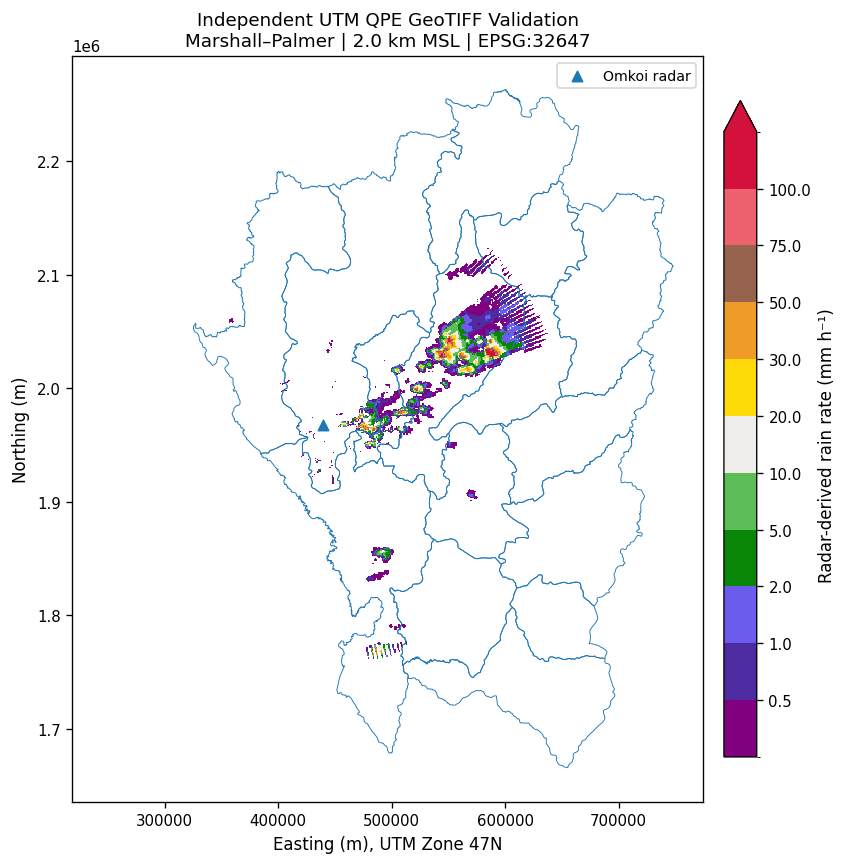

In [47]:
# CELL 47 — Independent UTM GeoTIFF validation figure

baseline_geotiff_row = (
    QPE_GEOTIFF_MANIFEST.loc[
        QPE_GEOTIFF_MANIFEST[
            "relation_id"
        ]
        == BASE_RELATION
    ]
)

if baseline_geotiff_row.empty:
    raise RuntimeError(
        "ไม่พบ baseline QPE GeoTIFF"
    )

BASELINE_UTM_GEOTIFF = Path(
    baseline_geotiff_row.iloc[
        0
    ][
        "UTM_path"
    ]
)

with rasterio.open(
    BASELINE_UTM_GEOTIFF
) as src:

    raster_qpe = src.read(
        1,
        masked=True,
    )

    raster_bounds = (
        src.bounds
    )

    raster_crs = (
        src.crs
    )


adm1_utm = adm1_clip.to_crs(
    raster_crs
)

radar_easting, radar_northing = (
    to_utm.transform(
        radar_lon,
        radar_lat,
    )
)

fig = plt.figure(
    figsize=(
        8.1,
        7.1,
    )
)

ax = fig.add_subplot(
    111
)

display_raster = np.ma.masked_less(
    raster_qpe,
    RAIN_RATE_BOUNDS_MMH[
        0
    ],
)

image = ax.imshow(
    display_raster,
    extent=[
        raster_bounds.left,
        raster_bounds.right,
        raster_bounds.bottom,
        raster_bounds.top,
    ],
    origin="upper",
    cmap=RAIN_CMAP,
    norm=RAIN_NORM,
    interpolation="nearest",
)

adm1_utm.boundary.plot(
    ax=ax,
    linewidth=0.55,
)

ax.scatter(
    radar_easting,
    radar_northing,
    marker="^",
    s=38,
    label="Omkoi radar",
)

cbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.025,
    shrink=0.88,
    boundaries=(
        RAIN_RATE_BOUNDS_MMH
    ),
    ticks=(
        RAIN_RATE_BOUNDS_MMH[
            1:-1
        ]
    ),
    extend="max",
)

cbar.set_label(
    "Radar-derived rain rate (mm h⁻¹)"
)

ax.set_xlabel(
    (
        "Easting (m), UTM Zone "
        f"{UTM_INFO['zone']}"
        f"{UTM_INFO['hemisphere']}"
    )
)

ax.set_ylabel(
    "Northing (m)"
)

ax.set_title(
    (
        "Independent UTM QPE GeoTIFF Validation\n"
        f"Marshall–Palmer | "
        f"{QPE_ACTUAL_HEIGHT_KM_MSL:.1f} km MSL | "
        f"EPSG:{UTM_INFO['epsg']}"
    )
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "04_fig11_UTM_QPE_GeoTIFF_validation.png"
)

save_figure(
    fig,
    F,
    source_file=selected_filename,
    product="QPE GeoTIFF validation",
    relation_id=BASE_RELATION,
    processing=(
        "Independent Rasterio reopen of UTM QPE GeoTIFF."
    ),
    units="mm h-1",
    time_UTC=str(
        observation_time_UTC
    ),
)

plt.show()

# 31. Rain rate ไม่เท่ากับ rainfall accumulation

Notebook 04 คำนวณ:

\[
R
\quad
[mm\,h^{-1}]
\]

ซึ่งเป็น **อัตรา**

ยังไม่ใช่ rainfall depth:

\[
P
\quad
[mm]
\]

ถ้า rain rate คงที่ \(R\) ในช่วงเวลา \(\Delta t\):

\[
P=R\Delta t
\]

เช่น:

\[
R=20\;mm\,h^{-1}
\]

และ:

\[
\Delta t=6\;min=0.1\;h
\]

จะได้:

\[
P=2\;mm
\]

Notebook 05 จะใช้ actual scan timestamps เพื่อทำ temporal integration

> **ห้าม**
>
> บวก dBZ จากหลาย scans เพื่อหาฝนสะสม

# 32. ข้อจำกัดเชิงวิทยาศาสตร์ของ QPE ในเหตุการณ์นี้

QPE ใน Notebook 04 เป็นตัวอย่างที่ดีเพราะเป็นกรณียากจริง

### 1. Hail contamination

High reflectivity ไม่ได้เกิดจาก liquid rain เพียงอย่างเดียว

### 2. CAPPI sampling

2-km MSL CAPPI อาจต่ำกว่า lowest native beam center บริเวณ main storm core

### 3. Vertical profile of reflectivity

Reflectivity aloft ไม่จำเป็นต้องเท่ากับ reflectivity ใกล้พื้น

### 4. No gauge validation

ยังไม่มี gauge truth ใน Notebook นี้

### 5. Single Z–R relation cannot represent all microphysics

ฝน convective, stratiform และ mixed-phase มี particle distributions ต่างกัน

### 6. Cartesian interpolation

QPE รับ uncertainty ต่อมาจาก radar gridding ใน Notebook 03

ดังนั้น output ควรเรียกว่า:

```text
radar-derived rain-rate estimate
```

มากกว่า:

```text
observed rainfall
```

# 33. Export processing metadata สำหรับ reproducibility

In [48]:
# CELL 48 — QPE processing metadata

QPE_PROCESSING_METADATA = pd.DataFrame({
    "parameter": [
        "event_id",
        "event_type",
        "radar_site",
        "radar_band",
        "source_radar_file",
        "source_grid_NetCDF",
        "observation_time_UTC",
        "source_field",
        "requested_QPE_CAPPI_km_MSL",
        "actual_QPE_CAPPI_km_MSL",
        "nearest_native_elevation_deg_at_core_range",
        "nearest_beam_center_km_MSL_at_core_range",
        "absolute_vertical_mismatch_km",
        "QPE_ZH_min_dBZ",
        "QPE_ZH_upper_clipping",
        "hail_caution_thresholds_dBZ",
        "baseline_ZR_relation",
        "ZR_relations",
        "supported_low_ZH_handling",
        "missing_radar_handling",
        "point_mode",
        "point_lon",
        "point_lat",
        "point_UTM_zone",
        "point_UTM_EPSG",
        "point_easting_m",
        "point_northing_m",
        "GeoTIFF_native_CRS",
        "GeoTIFF_target_CRS",
        "GeoTIFF_reprojection_resampling",
        "interpretation",
    ],
    "value": [
        ACTIVE_EVENT.get(
            "event_id"
        ),
        ACTIVE_EVENT.get(
            "event_type"
        ),
        "Omkoi",
        COURSE_CONFIG[
            "radar"
        ].get(
            "band"
        ),
        selected_filename,
        str(
            FULL_GRID_NETCDF
        ),
        str(
            observation_time_UTC
        ),
        FIELD_Z,
        QPE_CAPPI_MSL_KM,
        QPE_ACTUAL_HEIGHT_KM_MSL,
        QPE_NEAREST_ELEVATION_DEG,
        QPE_NEAREST_BEAM_KM_MSL,
        QPE_VERTICAL_MISMATCH_KM,
        QPE_ZH_MIN_DBZ,
        (
            "none"
        ),
        str(
            HAIL_CAUTION_LEVELS_DBZ
        ),
        BASE_RELATION,
        str(
            {
                key: value[
                    "equation"
                ]
                for key, value in (
                    ZR_RELATIONS.items()
                )
            }
        ),
        (
            "Valid radar pixels below threshold are set to 0 mm h-1."
        ),
        (
            "No radar support remains masked / NoData."
        ),
        POINT_MODE,
        POINT_LON,
        POINT_LAT,
        (
            f"{UTM_INFO['zone']}"
            f"{UTM_INFO['hemisphere']}"
        ),
        UTM_INFO[
            "epsg"
        ],
        POINT_EASTING_M,
        POINT_NORTHING_M,
        str(
            NATIVE_AEQD_CRS
        ),
        (
            f"EPSG:{UTM_INFO['epsg']}"
        ),
        "nearest",
        (
            "Radar-derived Z-R rain-rate sensitivity products; "
            "not gauge-validated and not direct surface rainfall observations."
        ),
    ],
})

display(
    QPE_PROCESSING_METADATA
)

QPE_PROCESSING_METADATA_CSV = (
    OUTPUT_CSV_DIR
    / "04_QPE_processing_metadata.csv"
)

QPE_PROCESSING_METADATA.to_csv(
    QPE_PROCESSING_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    QPE_PROCESSING_METADATA_CSV,
)

,parameter,value
0,event_id,20230318_observed_hail_1106_1200
1,event_type,observed_hail
2,radar_site,Omkoi
3,radar_band,S
4,source_radar_file,20230318111202.uf.gz
5,source_grid_NetCDF,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...
6,observation_time_UTC,2023-03-18 11:12:02+00:00
7,source_field,corrected_reflectivity
8,requested_QPE_CAPPI_km_MSL,2.0
9,actual_QPE_CAPPI_km_MSL,2.0


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/04_QPE_processing_metadata.csv


# 34. Export figure manifest

In [49]:
# CELL 49 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    FIGURE_RECORDS
)

FIGURE_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "04_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST
)

print(
    "Saved:",
    FIGURE_MANIFEST_CSV,
)

,figure_name,figure_path,product,processing,units,dpi,source_file,relation_id,CAPPI_height_km_MSL,field,time_UTC,colormap,baseline_relation
0,04_fig01_ZR_theoretical_sensitivity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,Z-R theoretical sensitivity,Analytical conversion from dBZ to rain rate; n...,mm h-1,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,04_QPE_full_MP_200_1.6_2.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,radar-derived rain rate,ZH >= 10.0 dBZ converted with Z = 200 R^1.6; 5...,mm h-1,300,20230318111202.uf.gz,MP_200_1.6,2.0,corrected_reflectivity,2023-03-18 11:12:02+00:00,RRate11,NaN
2,04_QPE_full_CONV_300_1.4_2.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,radar-derived rain rate,ZH >= 10.0 dBZ converted with Z = 300 R^1.4; 5...,mm h-1,300,20230318111202.uf.gz,CONV_300_1.4,2.0,corrected_reflectivity,2023-03-18 11:12:02+00:00,RRate11,NaN
3,04_QPE_full_TROP_250_1.2_2.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,radar-derived rain rate,ZH >= 10.0 dBZ converted with Z = 250 R^1.2; 5...,mm h-1,300,20230318111202.uf.gz,TROP_250_1.2,2.0,corrected_reflectivity,2023-03-18 11:12:02+00:00,RRate11,NaN
4,04_QPE_storm_MP_200_1.6_2.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,storm-focused radar-derived rain rate,Storm ROI from Notebook 02; no upper reflectiv...,mm h-1,300,20230318111202.uf.gz,MP_200_1.6,2.0,NaN,2023-03-18 11:12:02+00:00,RRate11,NaN
5,04_QPE_storm_CONV_300_1.4_2.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,storm-focused radar-derived rain rate,Storm ROI from Notebook 02; no upper reflectiv...,mm h-1,300,20230318111202.uf.gz,CONV_300_1.4,2.0,NaN,2023-03-18 11:12:02+00:00,RRate11,NaN
6,04_QPE_storm_TROP_250_1.2_2.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,storm-focused radar-derived rain rate,Storm ROI from Notebook 02; no upper reflectiv...,mm h-1,300,20230318111202.uf.gz,TROP_250_1.2,2.0,NaN,2023-03-18 11:12:02+00:00,RRate11,NaN
7,04_QPE_difference_CONV_300_1.4_minus_MP_200_1....,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,Z-R sensitivity difference,Alternative Z-R rain rate minus Marshall-Palme...,mm h-1,300,20230318111202.uf.gz,CONV_300_1.4,NaN,NaN,2023-03-18 11:12:02+00:00,NaN,MP_200_1.6
8,04_QPE_difference_TROP_250_1.2_minus_MP_200_1....,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,Z-R sensitivity difference,Alternative Z-R rain rate minus Marshall-Palme...,mm h-1,300,20230318111202.uf.gz,TROP_250_1.2,NaN,NaN,2023-03-18 11:12:02+00:00,NaN,MP_200_1.6
9,04_fig08_QPE_distribution_sensitivity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,QPE distribution sensitivity,Positive storm-ROI rain-rate pixels; compariso...,mm h-1,300,20230318111202.uf.gz,NaN,NaN,NaN,2023-03-18 11:12:02+00:00,NaN,NaN


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/04_figure_manifest.csv


# 35. แนวทางเขียน Methods

ค่าจริงควรถูกดึงจาก:

```text
03_grid_configuration.csv
03_CAPPI_nearest_beam_sampling.csv
04_ZR_relation_parameters.csv
04_QPE_processing_metadata.csv
```

ตัวอย่างโครงสร้าง Methods:

> Corrected reflectivity from the peak observed-hail radar volume was extracted from the 2-km MSL Cartesian CAPPI generated in the preceding three-dimensional gridding workflow. Reflectivity in dBZ was converted to linear reflectivity factor using \(Z=10^{dBZ/10}\). Radar-derived rain rates were calculated using three Z–R relationships to quantify methodological sensitivity, with the Marshall–Palmer relationship (\(Z=200R^{1.6}\)) used as the baseline. Valid radar-supported pixels with corrected reflectivity below 10 dBZ were assigned zero rain rate, whereas pixels without radar support remained NoData. Reflectivity values were not upper-clipped. Because the event was hail producing, areas exceeding 50, 55 and 60 dBZ were retained but flagged as regions where Z–R rainfall estimates required additional caution. No rain-gauge bias correction or validation was applied.

ก่อนนำไปใช้ใน manuscript ต้องตรวจว่าค่าทุกตัวตรงกับ CSV ที่รันจริง

# 36. CORE — แบบฝึกหัดสำหรับปริญญาตรี

### แบบฝึกหัด 1 — dBZ → Z

คำนวณ \(Z\) สำหรับ:

```text
20
30
40
50 dBZ
```

แล้วอธิบายว่าการเพิ่ม 10 dBZ หมายถึงอะไรใน linear scale

### แบบฝึกหัด 2 — Z–R

ใช้ Marshall–Palmer:

\[
Z=200R^{1.6}
\]

คำนวณ \(R\) เมื่อ:

```text
ZH = 30
40
50 dBZ
```

### แบบฝึกหัด 3 — Rain rate ไม่ใช่ rainfall accumulation

ถ้า:

\[
R=30\;mm\,h^{-1}
\]

นาน 6 นาที ปริมาณฝนเท่ากับกี่ mm?

### แบบฝึกหัด 4 — Point extraction

ใช้ `04_point_extraction.csv` รายงาน:

- requested coordinate
- nearest grid coordinate
- offset distance
- corrected ZH
- rain rate จากทั้งสาม Z–R relations

# 37. ADVANCED / MSc — แบบฝึกหัด

### แบบฝึกหัด 5 — Z–R sensitivity

ใช้ `04_QPE_sensitivity_summary.csv`

เปรียบเทียบ alternative relations กับ Marshall–Palmer ใน storm ROI

อภิปราย:

- median difference
- P95 difference
- ratio

### แบบฝึกหัด 6 — Hail contamination

ใช้ `04_ZR_reference_values.csv`

ดู rain rate ที่:

```text
50
55
60
65
70 dBZ
```

อภิปรายว่าค่าใดเริ่มไม่สมเหตุสมผลหากตีความเป็น liquid rainfall เพียงอย่างเดียว

### แบบฝึกหัด 7 — CAPPI sampling

จาก sampling diagnostic:

- 2-km CAPPI อยู่ห่าง nearest beam center เท่าใด?
- mismatch นี้มีผลต่อ QPE interpretation อย่างไร?

### แบบฝึกหัด 8 — Native gate vs Cartesian grid

ใช้ `04_native_gate_vs_CAPPI_point.csv`

เปรียบเทียบ:

```text
native gate altitude
native gate ZH
CAPPI height
CAPPI ZH
```

อธิบายว่าเหตุใดค่าจึงไม่จำเป็นต้องเท่ากัน

# 38. RESEARCH — แบบฝึกหัดสำหรับการต่อยอดงานตีพิมพ์

### แบบฝึกหัด 9 — Threshold sensitivity

ทดลอง:

```python
QPE_ZH_MIN_DBZ = 5
QPE_ZH_MIN_DBZ = 10
QPE_ZH_MIN_DBZ = 15
```

ตรวจผลต่อ:

- wet fraction
- mean rain rate
- spatial coverage

### แบบฝึกหัด 10 — CAPPI-height sensitivity

ทดลอง QPE ที่:

```text
2 km MSL
4 km MSL
```

แล้วอภิปรายว่า:

- beam sampling ต่างกันอย่างไร?
- vertical reflectivity structure มีผลอย่างไร?
- ระดับไหนเหมาะกับ near-surface rainfall inference มากกว่าใน event นี้?

**ห้าม** สรุปว่า 4 km ดีกว่า 2 km เพียงเพราะ sampling mismatch ต่ำกว่า ต้องพิจารณาวัตถุประสงค์ของ QPE ด้วย

### แบบฝึกหัด 11 — Publication figure

เลือก full-domain หรือ storm-focused QPE map แล้วเขียน caption ที่ระบุ:

- radar site
- radar band
- UTC time
- CAPPI height
- Z–R relation
- ZH threshold
- hail-contamination contours
- GIS boundaries
- ข้อจำกัดว่าเป็น radar-derived estimate

# 39. สิ่งที่ Notebook 04 ยังไม่ทำ

Notebook นี้ยังไม่ทำ:

- rain-gauge validation
- rain-gauge bias correction
- KDP rainfall
- polarimetric blended rainfall
- temporal accumulation
- hourly rainfall
- zonal statistics
- runoff modeling
- hail retrieval

เหตุผลคือการเรียนควรแยก:

```text
instantaneous rain-rate estimation
```

ออกจาก:

```text
temporal rainfall accumulation
```

Notebook 05 จะทำขั้นต่อไป:

\[
P=\sum_i R_i\Delta t_i
\]

โดยใช้ actual radar timestamps ของทั้ง 10 volumes

# 40. Output inventory

In [50]:
# CELL 50 — Output inventory

EXPECTED_OUTPUTS = [
    ZR_PARAMETER_CSV,
    ZR_REFERENCE_CSV,
    HAIL_FLAG_SUMMARY_CSV,
    QPE_SUMMARY_CSV,
    QPE_SENSITIVITY_CSV,
    POINT_EXTRACTION_CSV,
    NATIVE_GATE_COMPARISON_CSV,
    QPE_GEOTIFF_MANIFEST_CSV,
    QPE_GEOTIFF_VALIDATION_CSV,
    QPE_PROCESSING_METADATA_CSV,
    FIGURE_MANIFEST_CSV,
]

output_inventory = pd.DataFrame({
    "path": [
        str(
            path
        )
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
    "exists": [
        Path(
            path
        ).exists()
        for path in (
            EXPECTED_OUTPUTS
        )
    ],
})

display(
    output_inventory
)

,path,exists
0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
1,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
2,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
3,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
4,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
5,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
6,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
7,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
8,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
9,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True


# 41. Final readiness check

In [51]:
# CELL 51 — Notebook 04 readiness

checks = []


def add_check(
    item,
    passed,
    note="",
):
    checks.append({
        "item": (
            item
        ),
        "status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "note": (
            note
        ),
    })


add_check(
    "Notebook 03 readiness",
    bool(
        (
            readiness_03[
                "status"
            ]
            == "PASS"
        ).all()
    ),
)

add_check(
    "Active event is observed hail",
    ACTIVE_EVENT.get(
        "event_type"
    )
    == "observed_hail",
)

add_check(
    "Full-domain 3-D Grid NetCDF readable",
    full_grid
    is not None,
)

add_check(
    "Corrected reflectivity field available",
    FIELD_Z
    in full_grid.fields,
)

add_check(
    "QPE CAPPI extracted",
    ZH_CAPPI.count()
    > 0,
    (
        f"{QPE_ACTUAL_HEIGHT_KM_MSL:.1f} km MSL"
    ),
)

add_check(
    "QPE CAPPI sampling diagnostic available",
    np.isfinite(
        QPE_VERTICAL_MISMATCH_KM
    ),
    (
        f"Nearest beam mismatch = "
        f"{QPE_VERTICAL_MISMATCH_KM:.2f} km"
    ),
)

add_check(
    "Three Z-R relations configured",
    len(
        ZR_RELATIONS
    )
    == 3,
)

add_check(
    "Three rain-rate products created",
    len(
        RAIN_RATE_PRODUCTS
    )
    == 3,
)

add_check(
    "No scientific upper ZH clipping",
    QPE_ZH_MAX_DBZ
    is None,
)

add_check(
    "Supported weak-reflectivity pixels represented as zero rain",
    all(
        np.any(
            np.ma.asarray(
                rainfall
            ).filled(
                np.nan
            )
            == 0.0
        )
        for rainfall in (
            RAIN_RATE_PRODUCTS.values()
        )
    ),
)

add_check(
    "Hail-contamination caution flags created",
    HAIL_CAUTION_FLAG.shape
    == ZH_CAPPI.shape,
)

add_check(
    "QPE summary exported",
    QPE_SUMMARY_CSV.exists(),
)

add_check(
    "Z-R sensitivity summary exported",
    QPE_SENSITIVITY_CSV.exists(),
)

add_check(
    "Point extraction exported",
    POINT_EXTRACTION_CSV.exists(),
)

add_check(
    "Native-gate comparison exported",
    NATIVE_GATE_COMPARISON_CSV.exists(),
)

add_check(
    "Automatic UTM CRS derived",
    UTM_INFO[
        "epsg"
    ]
    > 0,
    (
        f"EPSG:{UTM_INFO['epsg']}"
    ),
)

add_check(
    "All QPE GeoTIFFs exported",
    (
        len(
            QPE_GEOTIFF_MANIFEST
        )
        == len(
            ZR_RELATIONS
        )
        and all(
            Path(
                path
            ).exists()
            for path in (
                QPE_GEOTIFF_MANIFEST[
                    "native_AEQD_path"
                ]
            )
        )
        and all(
            Path(
                path
            ).exists()
            for path in (
                QPE_GEOTIFF_MANIFEST[
                    "UTM_path"
                ]
            )
        )
    ),
)

add_check(
    "GeoTIFF validation exported",
    QPE_GEOTIFF_VALIDATION_CSV.exists(),
)

add_check(
    "No negative QPE values in validated GeoTIFFs",
    bool(
        (
            QPE_GEOTIFF_VALIDATION[
                "negative_value_count"
            ]
            == 0
        ).all()
    ),
)

add_check(
    "QPE processing metadata exported",
    QPE_PROCESSING_METADATA_CSV.exists(),
)

add_check(
    "Figure manifest exported",
    FIGURE_MANIFEST_CSV.exists(),
)


READINESS_04 = pd.DataFrame(
    checks
)

display(
    READINESS_04
)

NOTEBOOK_04_READY = bool(
    (
        READINESS_04[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_04_CSV = (
    OUTPUT_CSV_DIR
    / "04_readiness_check.csv"
)

READINESS_04.to_csv(
    READINESS_04_CSV,
    index=False,
)

print()

print(
    (
        "NOTEBOOK 04 READY FOR "
        "TEMPORAL RAINFALL ACCUMULATION AND ZONAL STATISTICS"
    )
    if NOTEBOOK_04_READY
    else "NOTEBOOK 04 REQUIRES REVIEW"
)

,item,status,note
0,Notebook 03 readiness,PASS,
1,Active event is observed hail,PASS,
2,Full-domain 3-D Grid NetCDF readable,PASS,
3,Corrected reflectivity field available,PASS,
4,QPE CAPPI extracted,PASS,2.0 km MSL
5,QPE CAPPI sampling diagnostic available,PASS,Nearest beam mismatch = 0.57 km
6,Three Z-R relations configured,PASS,
7,Three rain-rate products created,PASS,
8,No scientific upper ZH clipping,PASS,
9,Supported weak-reflectivity pixels represented...,PASS,



NOTEBOOK 04 READY FOR TEMPORAL RAINFALL ACCUMULATION AND ZONAL STATISTICS


# ข้อความสำคัญที่ต้องจำ

1. **dBZ ไม่ใช่ rain rate**
2. ต้องแปลง \(dBZ \rightarrow Z \rightarrow R\)
3. Z–R relation เป็น empirical relationship
4. ไม่มี Z–R relation เดียวที่เหมาะกับฝนทุกชนิด
5. การเปรียบเทียบ 3 relations ในบทนี้คือ **sensitivity analysis**
6. ยังไม่มี gauge validation
7. S-band ลดปัญหา attenuation บางส่วน แต่ไม่ได้ทำให้ QPE ไม่มี bias
8. Hail และ mixed-phase particles สามารถเพิ่ม reflectivity และทำให้ Z–R rain rate สูงเกินจริง
9. 50/55/60 dBZ ใน Notebook นี้เป็น **caution thresholds** ไม่ใช่ hail classes
10. Scientific QPE ไม่ถูก upper-clip ใน Notebook นี้
11. Display limit ไม่เท่ากับ data clipping
12. Valid radar support + weak ZH ต้องเป็น rain rate = 0
13. No radar support ต้องคงเป็น NoData
14. 2-km MSL CAPPI ไม่ใช่ direct surface rainfall observation
15. CAPPI sampling ต้องตีความร่วมกับ beam geometry
16. Nearest Cartesian grid cell ไม่ใช่ nearest native radar gate
17. Native gate และ CAPPI grid cell อาจมี ZH ต่างกันโดยไม่จำเป็นต้องมีอันใด “ผิด”
18. Rain rate \((mm\,h^{-1})\) ไม่เท่ากับ rainfall accumulation \((mm)\)
19. ห้ามบวก dBZ เพื่อหาฝนสะสม
20. Notebook 05 จะคำนวณ \(R_i\Delta t_i\) จาก actual radar timestamps

# Expected outputs

```text
event-specific 03_output/csv/
├── 04_ZR_relation_parameters.csv
├── 04_ZR_reference_values.csv
├── 04_hail_contamination_flag_summary.csv
├── 04_QPE_summary.csv
├── 04_QPE_sensitivity_summary.csv
├── 04_point_extraction.csv
├── 04_native_gate_vs_CAPPI_point.csv
├── 04_QPE_GeoTIFF_manifest.csv
├── 04_QPE_GeoTIFF_validation.csv
├── 04_QPE_processing_metadata.csv
├── 04_figure_manifest.csv
└── 04_readiness_check.csv
```

```text
event-specific 03_output/geotiff/
├── 04_QPE_MP_200_1.6_2.0kmMSL_native_AEQD.tif
├── 04_QPE_MP_200_1.6_2.0kmMSL_UTM47N.tif
├── 04_QPE_CONV_300_1.4_2.0kmMSL_native_AEQD.tif
├── 04_QPE_CONV_300_1.4_2.0kmMSL_UTM47N.tif
├── 04_QPE_TROP_250_1.2_2.0kmMSL_native_AEQD.tif
└── 04_QPE_TROP_250_1.2_2.0kmMSL_UTM47N.tif
```

ตัวอย่างรูปสำคัญ:

```text
event-specific 04_figures/04/
├── Z–R theoretical sensitivity
├── full-domain QPE × 3
├── storm-focused QPE × 3
├── Z–R difference maps
├── QPE distribution sensitivity
├── point extraction map
├── point Z–R sensitivity
└── independent UTM GeoTIFF validation
```

เมื่อ cell สุดท้ายแสดง:

```text
NOTEBOOK 04 READY FOR TEMPORAL RAINFALL ACCUMULATION AND ZONAL STATISTICS
```

จึงเข้าสู่:

**Notebook 05 — Hourly Rainfall Accumulation and Administrative Zonal Statistics**

# Technical and scientific notes

Notebook นี้ออกแบบให้เป็น bridge จาก radar meteorology ไปสู่ environmental GIS/QPE

หัวใจไม่ใช่เพียงการเขียน function:

```python
R = (Z / a) ** (1 / b)
```

แต่คือการเข้าใจว่า output มี assumptions อะไรอยู่เบื้องหลัง

ก่อนนำ workflow ไปใช้กับเหตุการณ์อื่น ต้องตรวจใหม่:

- radar band
- calibration
- source reflectivity field
- CAPPI height
- sampling geometry
- precipitation regime
- Z–R coefficients
- gauge availability
- hail / mixed-phase contamination
- spatial support
- CRS

การใช้ code เดิมกับ dataset ใหม่โดยไม่ตรวจ assumptions สามารถให้ผลที่ดูสวย แต่ไม่ถูกต้องทางวิทยาศาสตร์